In [6]:
import numpy as np
import pandas as pd
import subprocess
import os
import sys
import argparse
import glob
import time
from astropy.io import fits as pyfits
import matplotlib.pyplot as plt
from urllib.request import urlopen
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.time import Time
from contextlib import closing
from astropy import units as u

In [7]:
# Stacked_df is before the filtering process, filtered is what we want to look at 

unfiltered_stacked_df = pd.read_pickle('unfiltered_stacked_results.pkl')
filtered_stacked_df = pd.read_pickle('filtered_stacked_results.pkl')

In [8]:
def sci_fmt(x, sig=2):
    exponent = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exponent
    return rf"{coeff:.2f} \times 10^{{{exponent}}}"

In [9]:
# This plots the type for whichever dataframe you're using (filtered or not filtered)

plt.rc('text', usetex=True)


def plot_stacks_for_type(
    df,
    which_type="Ia",
    *,
    type_col="type",
    array_col="stacked_array",
    time_col="time_interval",
    rms_col="rms",
    count_col="num_observations",
    peak_col="peak_L",
    cmap="inferno",
    ncols=None,
    savepath=None,
    individual_scaling=True
):

    sub = df[df[type_col] == which_type]

    if sub.empty:
        raise ValueError(f"No rows found with {type_col} == {which_type}")

    num = len(sub)

    if ncols is None:
        ncols = min(6, num)

    nrows = (num + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.0*ncols, 3.6*nrows)
    )

    axes = np.atleast_1d(axes).ravel()

    cols = [array_col, time_col, rms_col, count_col, peak_col]

    for ax, row in zip(axes, sub[cols].itertuples(index=False, name=None)):

        arr, tlabel, rms, nstack, peakL = row

        if individual_scaling:
            vmin, vmax = np.nanmin(arr), np.nanmax(arr)

        snr = peakL / rms if rms != 0 else np.nan

        ax.imshow(arr, cmap=cmap, interpolation="nearest",
                  vmin=vmin, vmax=vmax)

        ax.set_title(f"{tlabel}", fontsize=18)

        label = (
        rf"$N_{{\mathrm{{stack}}}} = {int(nstack)}$" "\n"
        rf"$L_{{\max}} = {sci_fmt(peakL)}$" "\n"
        rf"$\mathrm{{RMS}} = {sci_fmt(rms)}$" "\n"
    )

        ax.set_xlabel(label, fontsize=18, labelpad=12, ha="center")

        ax.xaxis.label.set_linespacing(1.6)

        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

        # simple consistent borders
        for spine in ax.spines.values():
            spine.set_linewidth(1)
            spine.set_edgecolor("black")

    for ax in axes[num:]:
        ax.axis("off")

    plt.subplots_adjust(hspace=0.9)

    if savepath:
        plt.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.show()

    return fig, axes

In [10]:
### Use this if you want to compare 


def plot_stacks_for_type_combined(
    df_all,
    df_filt,
    which_type="Ia",
    *,
    type_col="type",
    array_col="stacked_array",
    time_col="time_interval",
    rms_col="rms",
    count_col="num_observations",
    peak_col="peak_L",
    cmap="inferno",
    ncols=6,
    snr_threshold=5.0,
    title=None,
    savepath=None,
    individual_scaling=True,
    row_titles=("All", "Filtered")
):

    sub_all  = df_all[df_all[type_col] == which_type]
    sub_filt = df_filt[df_filt[type_col] == which_type]

    if sub_all.empty and sub_filt.empty:
        raise ValueError(f"No rows found with {type_col} == {which_type} in either dataframe")

    # Determine how many panels per row (can differ)
    num_all  = len(sub_all)
    num_filt = len(sub_filt)

    nrows_all  = (num_all  + ncols - 1) // ncols if num_all  > 0 else 1
    nrows_filt = (num_filt + ncols - 1) // ncols if num_filt > 0 else 1

    # Total rows in the matplotlib grid
    nrows = nrows_all + nrows_filt

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(4.2*ncols, 3.2*nrows)
    )
    axes = np.atleast_2d(axes)  # shape (nrows, ncols)

    cols = [array_col, time_col, rms_col, count_col, peak_col]

    def _plot_into_rowblock(sub, axes_block, block_label):
        """Plot a 'sub' dataframe into a contiguous block of rows in axes."""
        if sub.empty:
            # turn off all axes in this block if empty
            for ax in axes_block.ravel():
                ax.axis("off")
            return

        # optional: enforce consistent ordering by time label if needed
        # sub = sub.sort_values(time_col)

        flat_axes = axes_block.ravel()

        for ax, row in zip(flat_axes, sub[cols].itertuples(index=False, name=None)):
            arr, tlabel, rms, nstack, peakL = row

            if individual_scaling:
                vmin, vmax = np.nanmin(arr), np.nanmax(arr)
            else:
                vmin, vmax = None, None  # matplotlib defaults

            snr = peakL / rms if rms != 0 else np.nan

            ax.imshow(arr, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
            ax.set_title(f"{tlabel}", fontsize=11)

            ax.set_xlabel(
                rf"RMS: {rms:.3e}, Stacked: {int(nstack)}" "\n"
                rf"Max $L$: {peakL:.3e}, S/N: {snr:.2f}",
                fontsize=9
            )

            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

            edge = "lime" if (np.isfinite(snr) and snr >= snr_threshold) else "black"
            lw = 4 if edge == "lime" else 1
            for spine in ax.spines.values():
                spine.set_edgecolor(edge)
                spine.set_linewidth(lw)

        # turn off unused panels in this block
        used = len(sub)
        for ax in flat_axes[used:]:
            ax.axis("off")

        # Put a row label on the left of the first axis in the block
        # (doesn't affect your panel style)
        axes_block[0, 0].set_ylabel(block_label, fontsize=14, rotation=90, labelpad=20)

    # Split the axes grid into two blocks: top for all, bottom for filtered
    axes_all  = axes[:nrows_all, :]
    axes_filt = axes[nrows_all:, :]

    _plot_into_rowblock(sub_all,  axes_all,  row_titles[0])
    _plot_into_rowblock(sub_filt, axes_filt, row_titles[1])

    if title is None:
        title = rf"{which_type} stacks: {row_titles[0]} vs {row_titles[1]}"

    fig.suptitle(title, fontsize=18, x=0.5, y=0.985)
    plt.subplots_adjust(top=0.93, hspace=0.55)

    if savepath:
        plt.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.show()
    return fig, axes

In [25]:
plt.rc('text', usetex=True)

def plot_stacks_all_types_vertical(
    df,
    *,
    type_col="type",
    array_col="stacked_array",
    time_col="time_interval",
    rms_col="rms",
    count_col="num_observations",
    peak_col="peak_L",
    cmap="inferno",
    savepath=None,
    individual_scaling=False
):
    types = df[type_col].unique()
    nrows = len(types)
    ncols = df.groupby(type_col).size().max()

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(2.8*ncols, 3.8*nrows)
    )

    # force 2D axes array
    axes = np.atleast_2d(axes)
    if nrows == 1:
        axes = axes.reshape(1, -1)

    cols = [array_col, time_col, rms_col, count_col, peak_col]

    table_data = []
    im_for_cbar = None

    for i, which_type in enumerate(types):
        sub = df[df[type_col] == which_type]

        nsub = len(sub)
        offset = (ncols - nsub) // 2

        for j, row in enumerate(sub[cols].itertuples(index=False, name=None)):
            ax = axes[i, j + offset]

            arr, tlabel, rms, nstack, peakL = row
            
            table_data.append({
                "Type": which_type,
                "Time Interval": tlabel,
                "N_stack": int(nstack),
                "Peak L": peakL,
                "RMS": rms
            })

            if arr is None:
                ax.axis("off")
                continue

            snr_arr = arr / rms if rms != 0 else arr

            if individual_scaling:
                vmin, vmax = np.nanmin(snr_arr), np.nanmax(snr_arr)
            else:
                vmin, vmax = -3, 6
        

            im = ax.imshow(
                snr_arr,
                cmap=cmap,
                interpolation="nearest",
                vmin=vmin,
                vmax=vmax,
                origin='lower'
            )

            if im_for_cbar is None:
                im_for_cbar = im

            ax.set_title(f"{tlabel}", fontsize=18)

            # label = (
            #     rf"$N_{{\mathrm{{stack}}}} = {int(nstack)}$" "\n"
            #     rf"$L_{{\max}} = {sci_fmt(peakL)}$" "\n"
            #     rf"$\mathrm{{RMS}} = {sci_fmt(rms)}$" "\n"
            # )

            # ax.set_xlabel(label, fontsize=18, labelpad=12, ha="center")
            # ax.xaxis.label.set_linespacing(1.6)

            ax.tick_params(
                left=False, bottom=False,
                labelleft=False, labelbottom=False
            )

            for spine in ax.spines.values():
                spine.set_linewidth(1)
                spine.set_edgecolor("black")

        # turn off unused axes in that row
        for j in range(ncols):
            if not (offset <= j < offset + nsub):
                if j == 0:  # keep this axis for the row label
                    axes[i, j].set_xticks([])
                    axes[i, j].set_yticks([])
                    for spine in axes[i, j].spines.values():
                        spine.set_visible(False)
                else:
                    axes[i, j].axis("off")

        # put the type label at the left of the row
        axes[i, 0].set_ylabel(
            which_type.replace("_", " "),
            fontsize=22,
            rotation=90,
            labelpad=25,
            weight="bold"
        )

    plt.subplots_adjust(left=0.08, right=0.99, hspace=0.1, wspace=0.03)

    cbar = fig.colorbar(
            im_for_cbar,
            ax=axes,
            orientation="vertical",
            fraction=0.03,
            pad=0.02
        )
    cbar.set_label("S/N", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    if savepath:
        plt.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.show()

    return fig, axes

In [12]:
plot_df = filtered_stacked_df.copy()

In [18]:
def build_stacks_table(
    df,
    *,
    type_col="type",
    time_col="time_interval",
    rms_col="rms",
    count_col="num_observations",
    peak_col="peak_L"
):
    cols = [type_col, time_col, count_col, peak_col, rms_col]

    sub = df[cols].copy()

    # compute S/N safely
    sub["S/N"] = sub[peak_col] / sub[rms_col]
    sub.loc[sub[rms_col] == 0, "S/N"] = np.nan

    table_df = sub.rename(columns={
        type_col: "Type",
        time_col: "Time Interval",
        count_col: "N_stack",
        peak_col: "Peak L",
        rms_col: "RMS"
    })

    return table_df.reset_index(drop=True)

In [19]:
def format_stacks_table(df):
    df = df.copy()

    # physics quantities → sig figs
    df["Peak L"] = df["Peak L"].apply(
        lambda x: f"{x:.4g}" if pd.notna(x) else "NaN"
    )
    df["RMS"] = df["RMS"].apply(
        lambda x: f"{x:.4g}" if pd.notna(x) else "NaN"
    )

    # S/N → clean decimal
    df["S/N"] = df["S/N"].apply(
        lambda x: f"{x:.2f}" if pd.notna(x) else "NaN"
    )

    return df

In [21]:
table_df = format_stacks_table(build_stacks_table(plot_df))

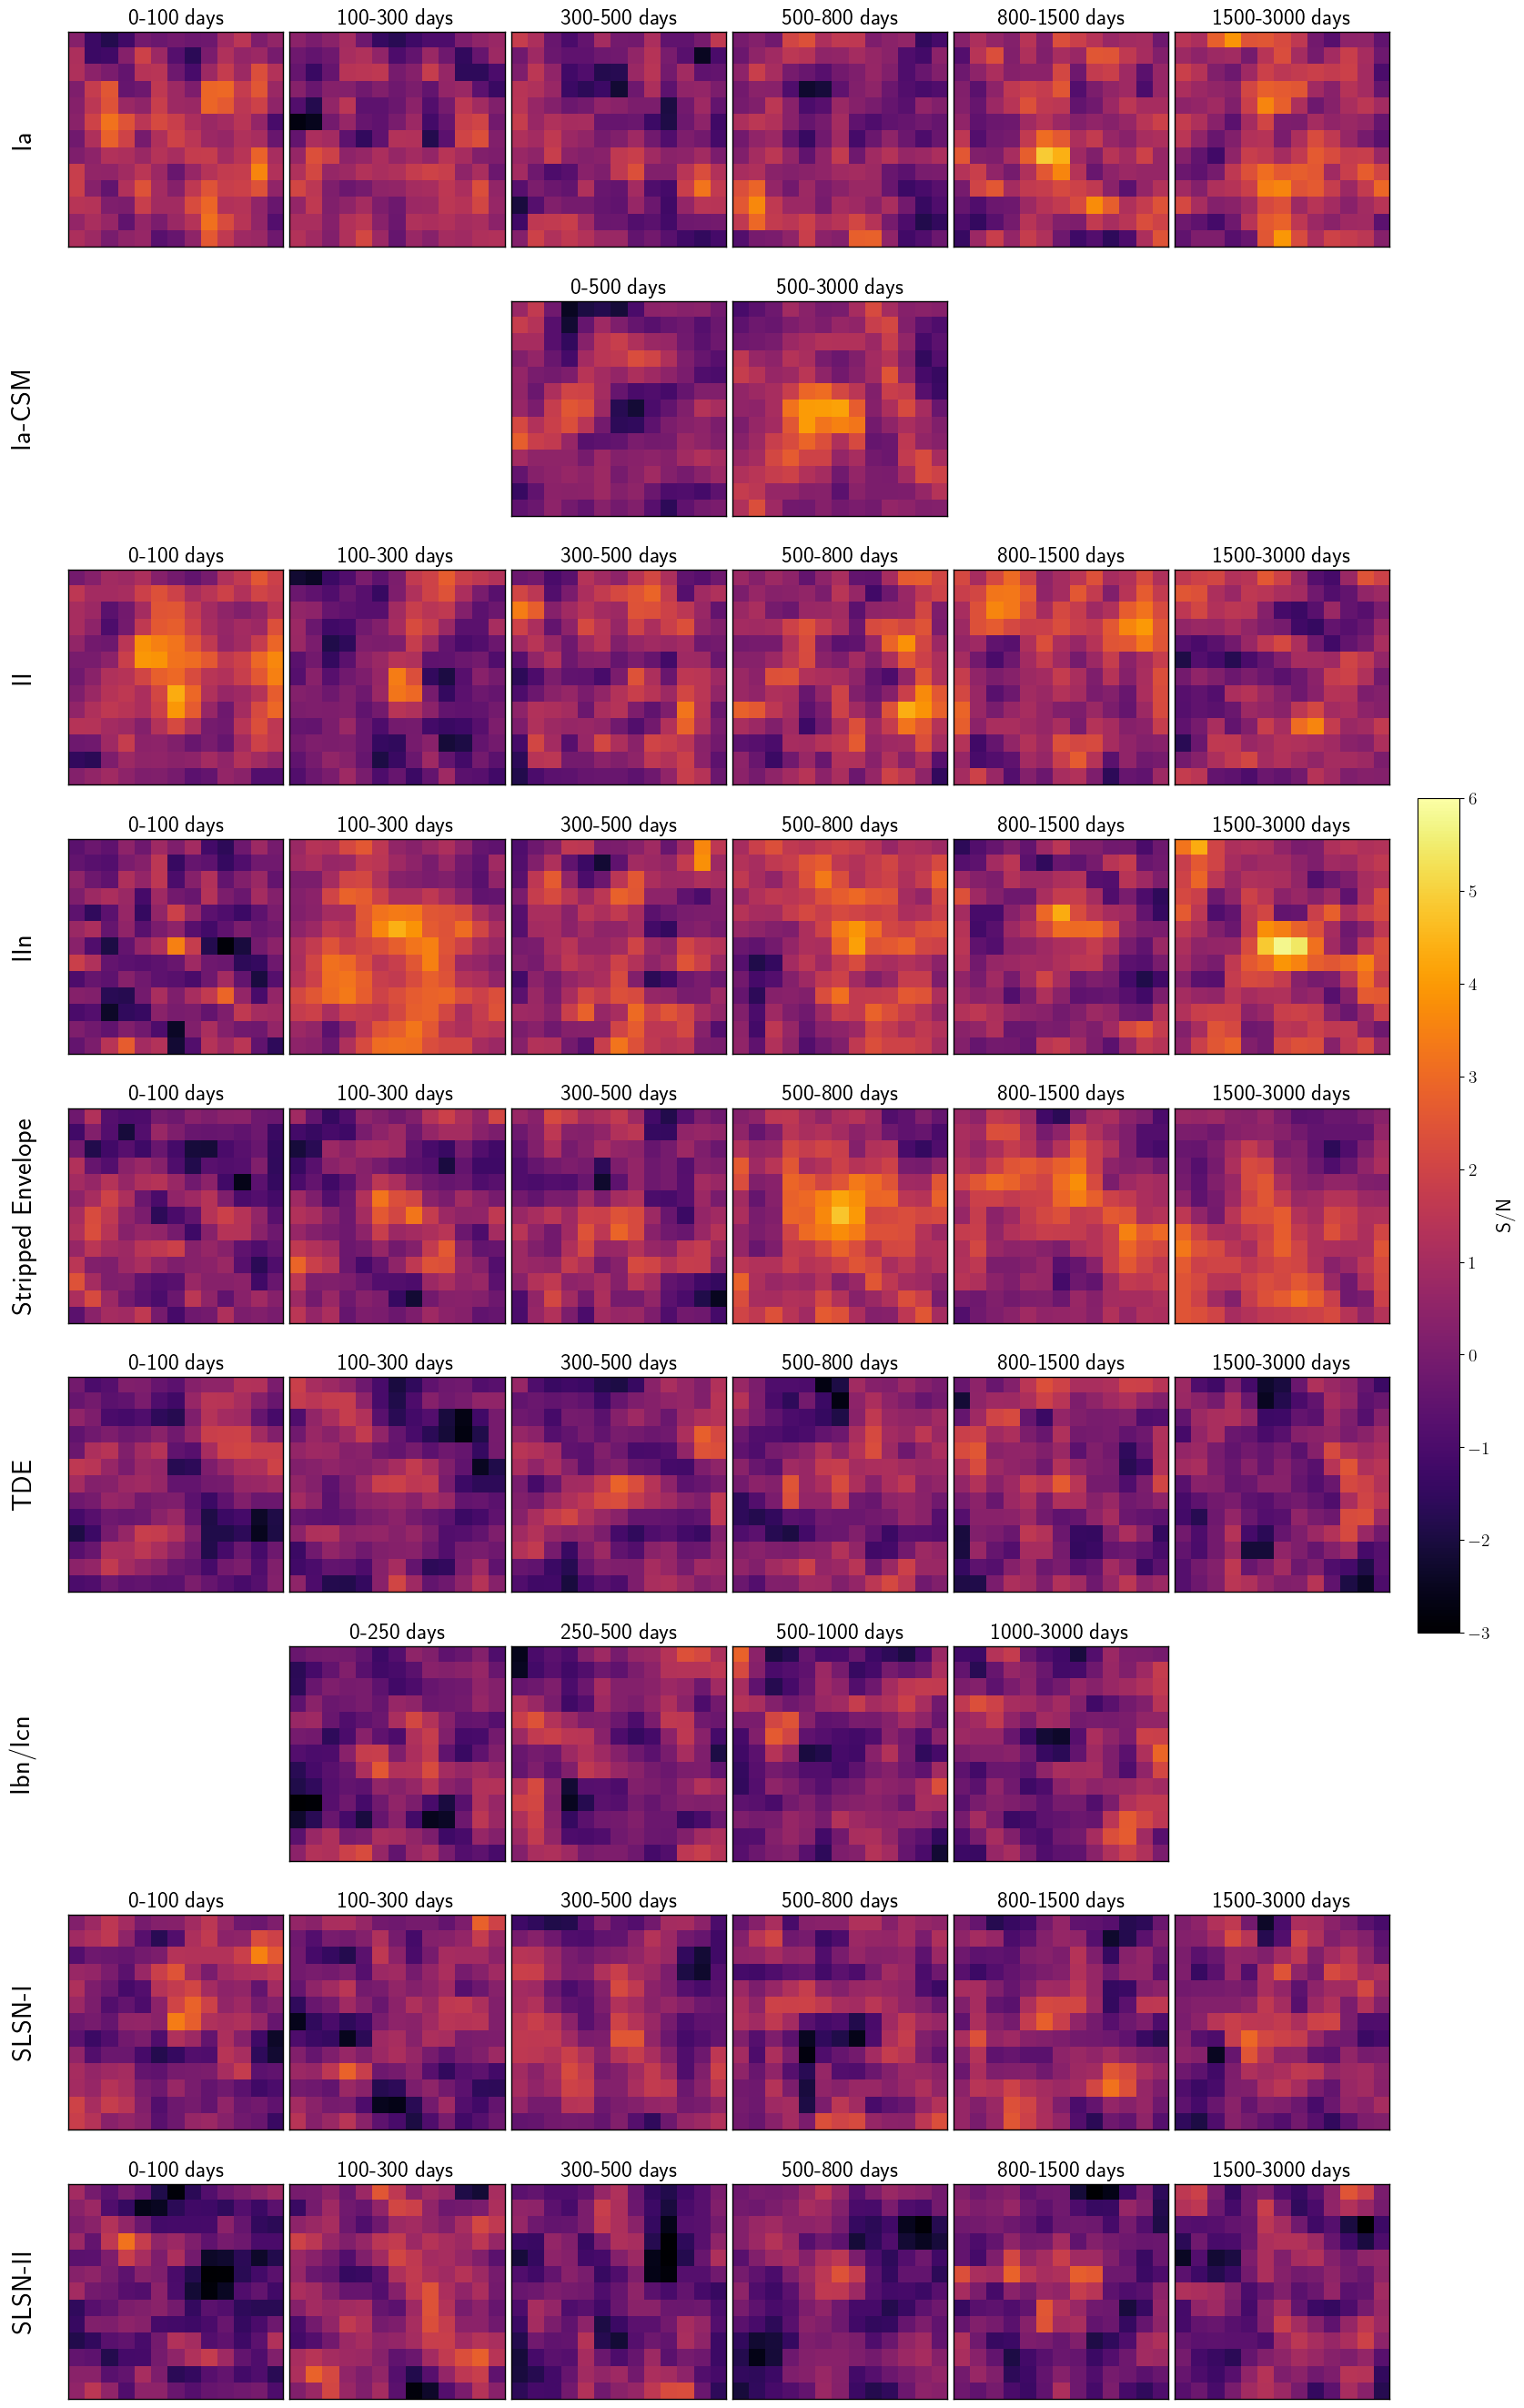

(<Figure size 1680x3420 with 55 Axes>,
 array([[<Axes: title={'center': '0-100 days'}, ylabel='Ia'>,
         <Axes: title={'center': '100-300 days'}>,
         <Axes: title={'center': '300-500 days'}>,
         <Axes: title={'center': '500-800 days'}>,
         <Axes: title={'center': '800-1500 days'}>,
         <Axes: title={'center': '1500-3000 days'}>],
        [<Axes: ylabel='Ia-CSM'>, <Axes: >,
         <Axes: title={'center': '0-500 days'}>,
         <Axes: title={'center': '500-3000 days'}>, <Axes: >, <Axes: >],
        [<Axes: title={'center': '0-100 days'}, ylabel='II'>,
         <Axes: title={'center': '100-300 days'}>,
         <Axes: title={'center': '300-500 days'}>,
         <Axes: title={'center': '500-800 days'}>,
         <Axes: title={'center': '800-1500 days'}>,
         <Axes: title={'center': '1500-3000 days'}>],
        [<Axes: title={'center': '0-100 days'}, ylabel='IIn'>,
         <Axes: title={'center': '100-300 days'}>,
         <Axes: title={'center': '300-5

In [26]:
plot_stacks_all_types_vertical(plot_df, savepath="stacked_types_1.pdf", individual_scaling=False)

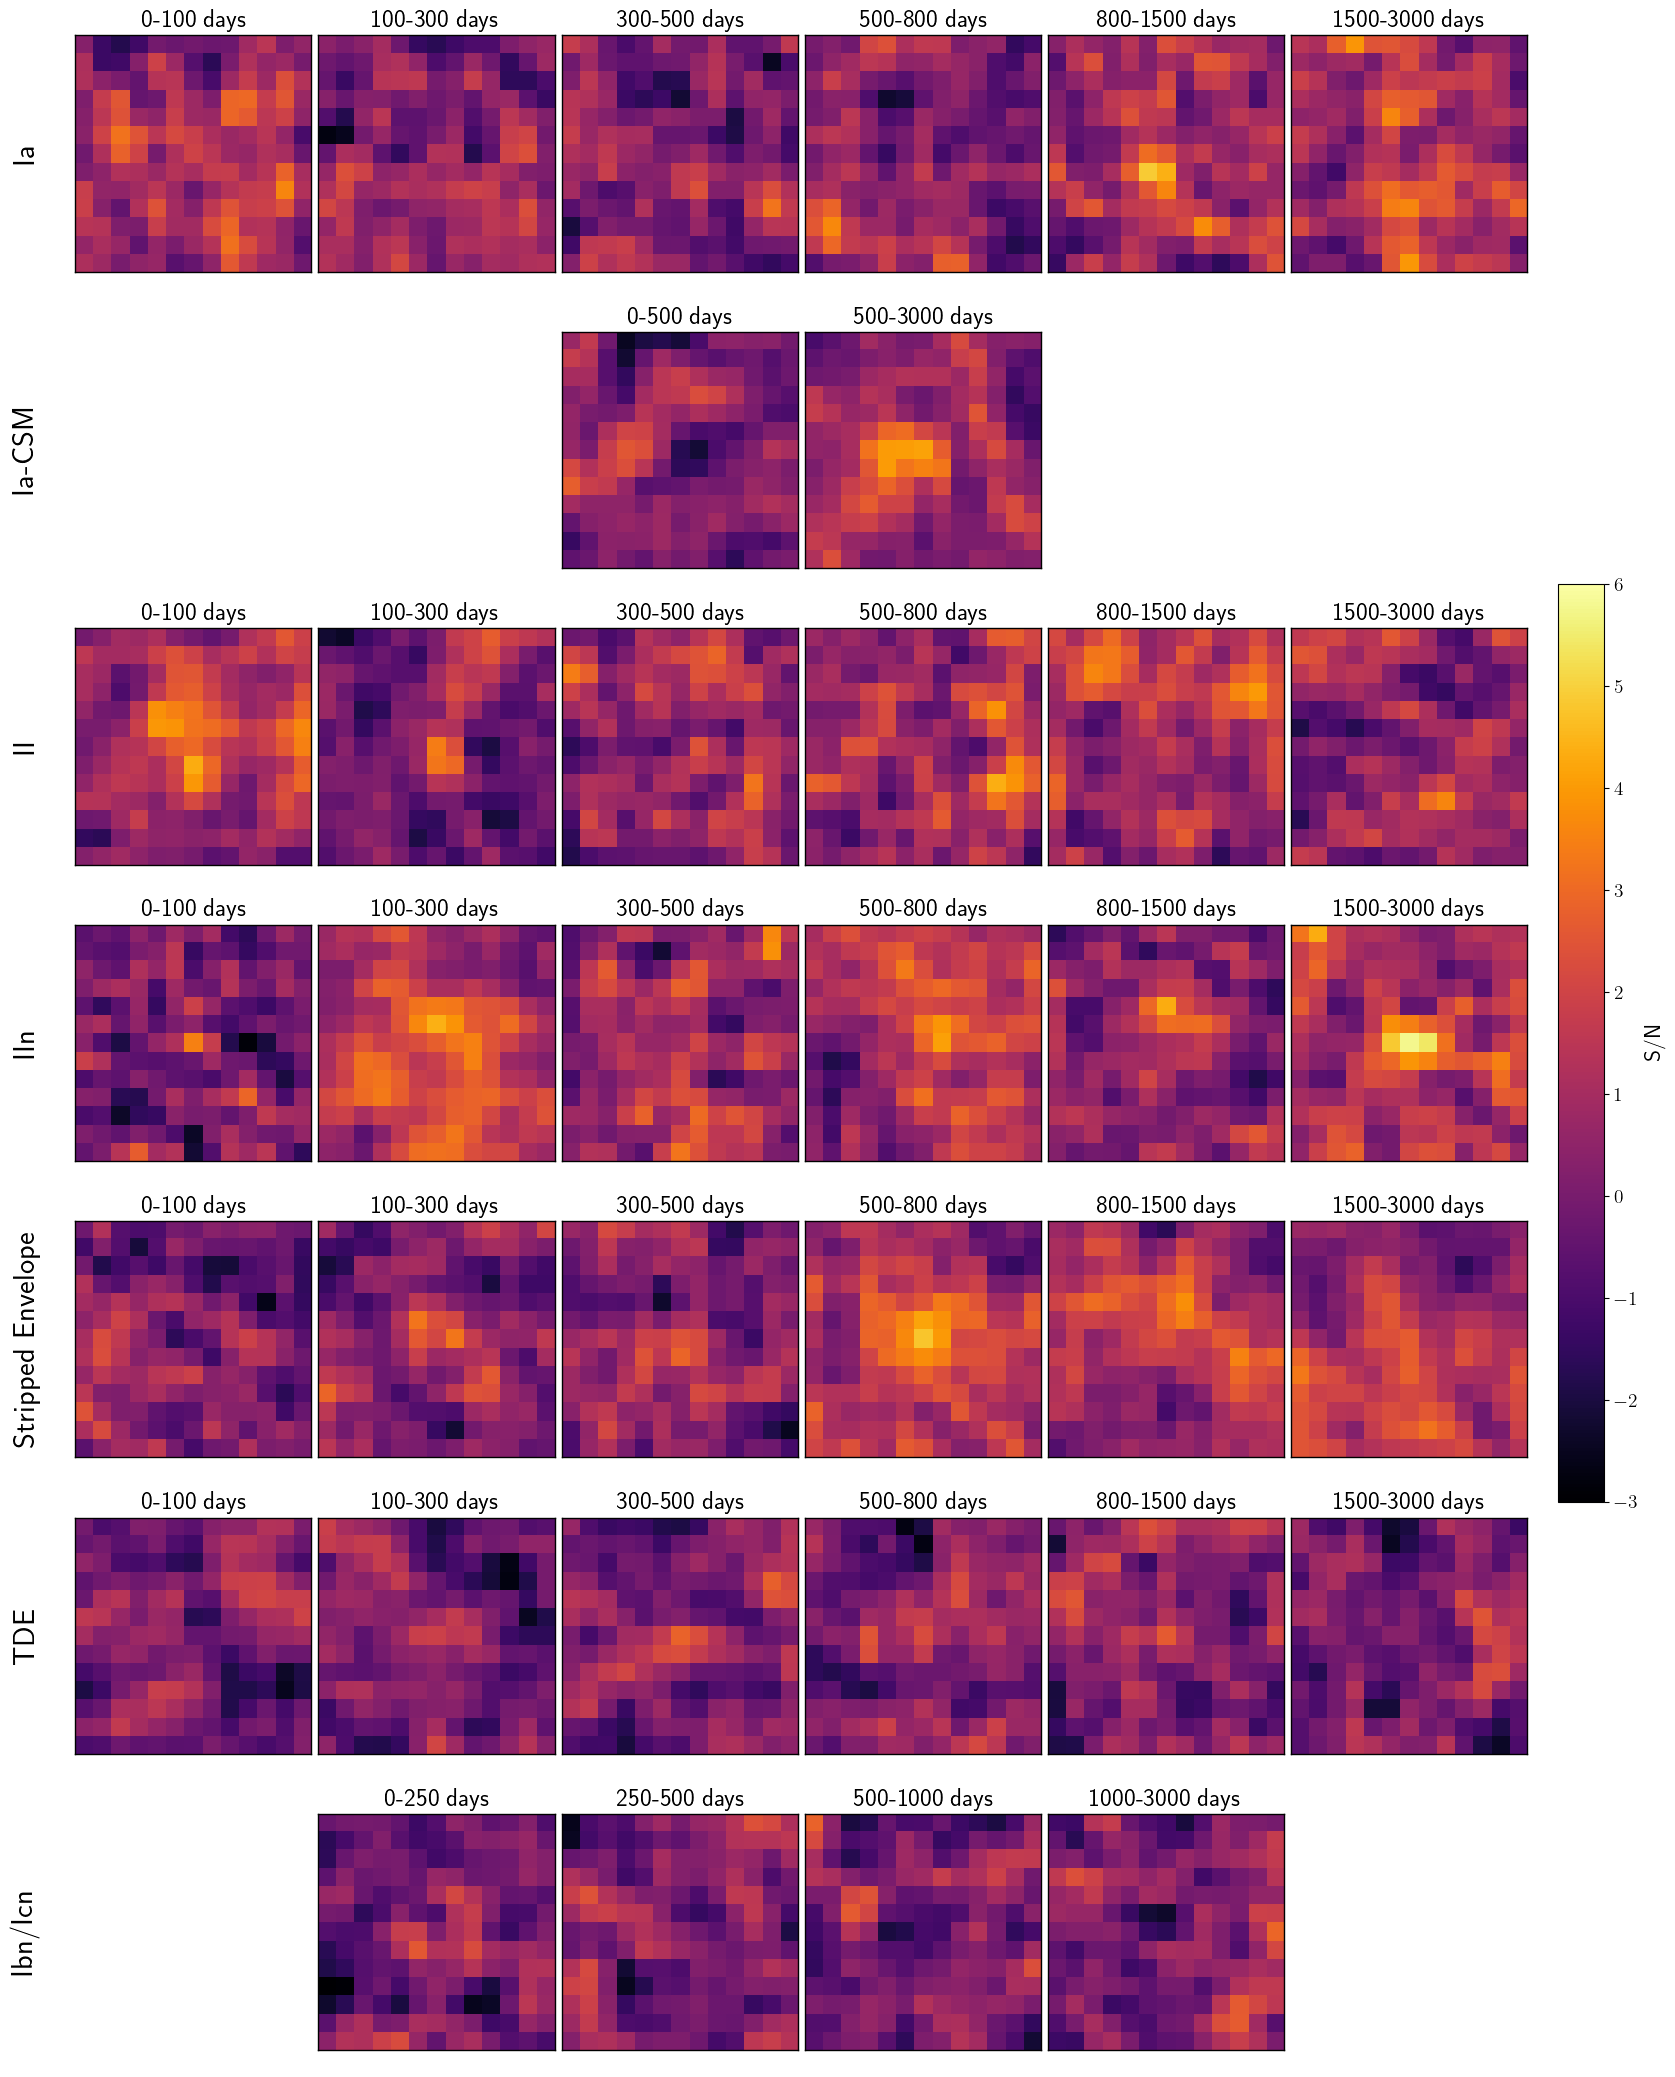

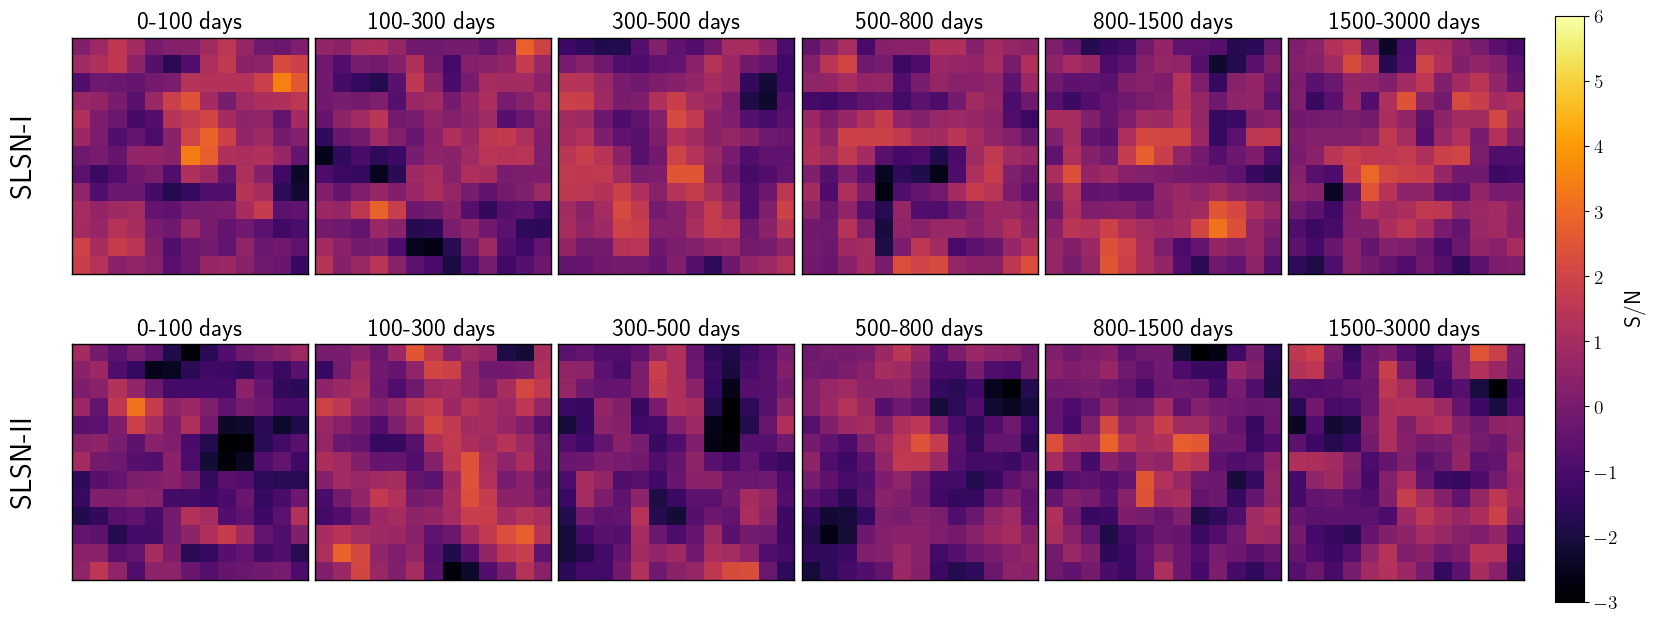

(<Figure size 1680x760 with 13 Axes>,
 array([[<Axes: title={'center': '0-100 days'}, ylabel='SLSN-I'>,
         <Axes: title={'center': '100-300 days'}>,
         <Axes: title={'center': '300-500 days'}>,
         <Axes: title={'center': '500-800 days'}>,
         <Axes: title={'center': '800-1500 days'}>,
         <Axes: title={'center': '1500-3000 days'}>],
        [<Axes: title={'center': '0-100 days'}, ylabel='SLSN-II'>,
         <Axes: title={'center': '100-300 days'}>,
         <Axes: title={'center': '300-500 days'}>,
         <Axes: title={'center': '500-800 days'}>,
         <Axes: title={'center': '800-1500 days'}>,
         <Axes: title={'center': '1500-3000 days'}>]], dtype=object))

In [27]:
types = plot_df["type"].drop_duplicates().tolist()

first_types = types[:7]
second_types = types[7:9]

plot_df_1 = plot_df[plot_df["type"].isin(first_types)].copy()
plot_df_2 = plot_df[plot_df["type"].isin(second_types)].copy()

plot_stacks_all_types_vertical(
    plot_df_1,
    savepath="stacked_types_1.pdf",
    individual_scaling=False
)

plot_stacks_all_types_vertical(
    plot_df_2,
    savepath="stacked_types_2.pdf",
    individual_scaling=False
)

In [ ]:
# Example of using the above function:

# plot_stacks_for_type_combined(stacked_df, filtered_stacked_df, 'Ia')

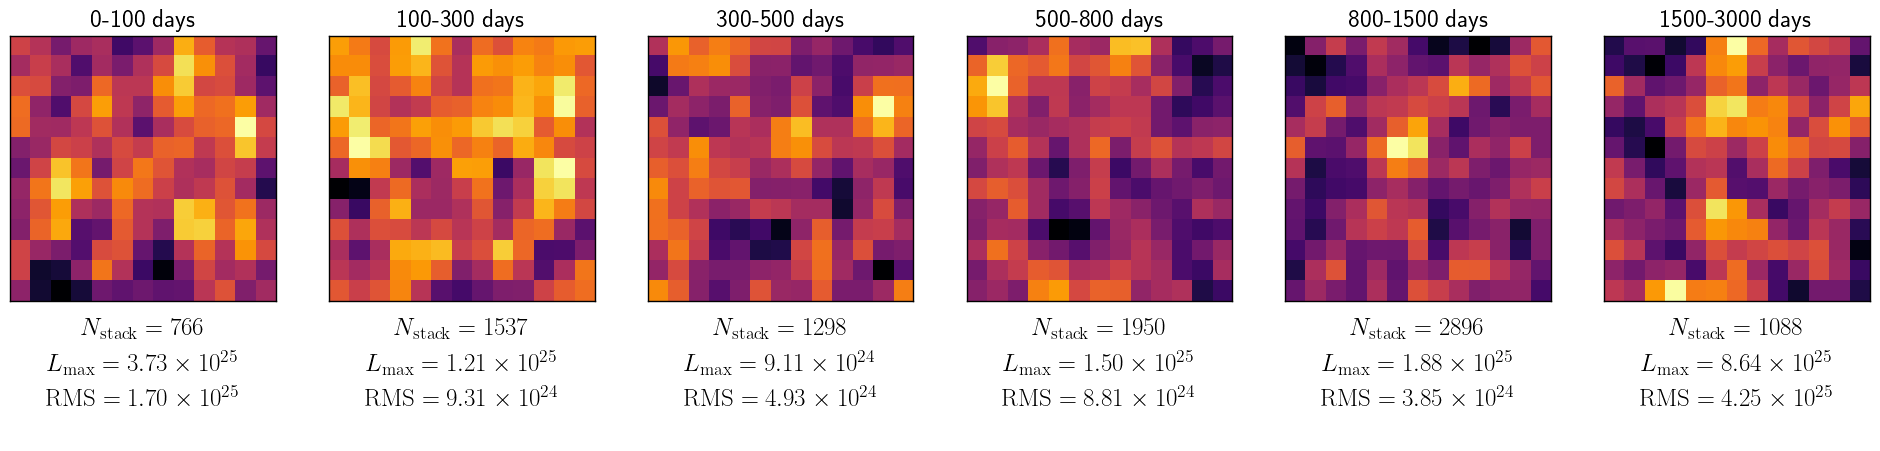

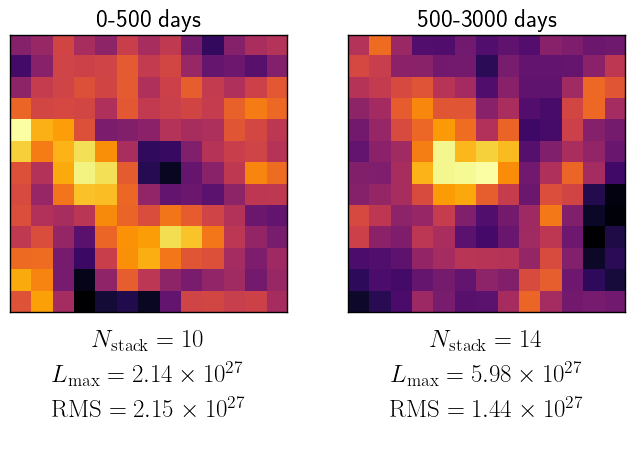

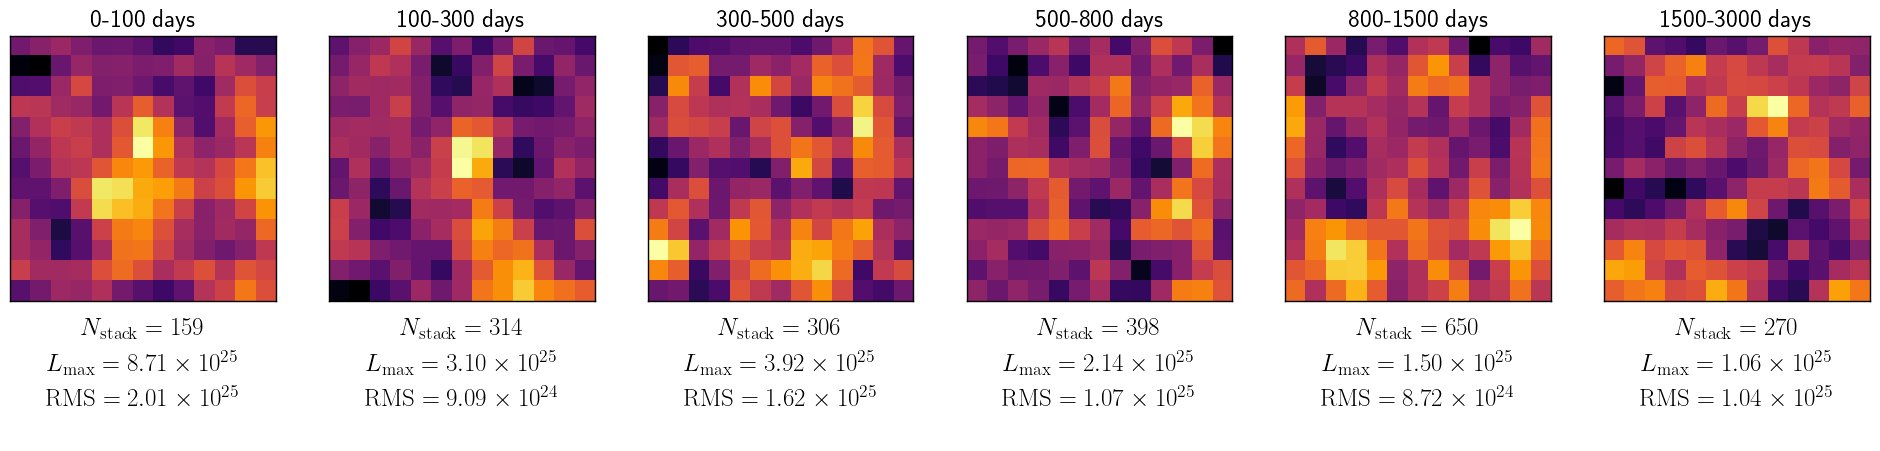

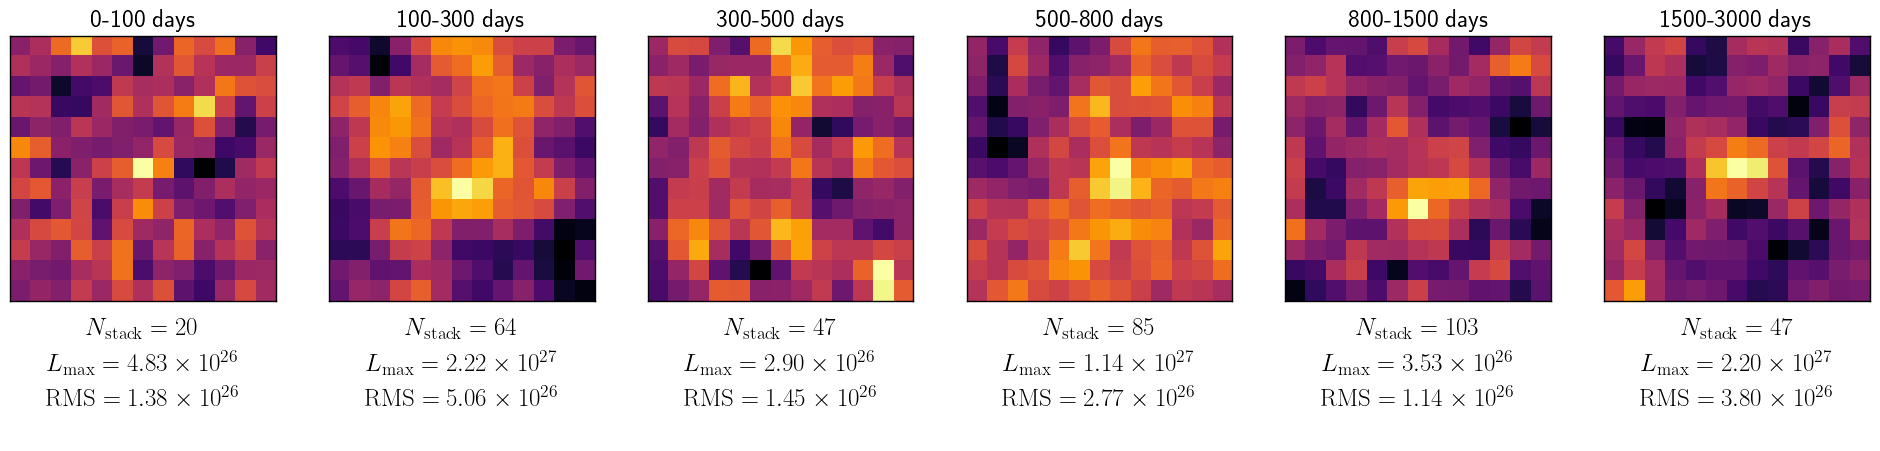

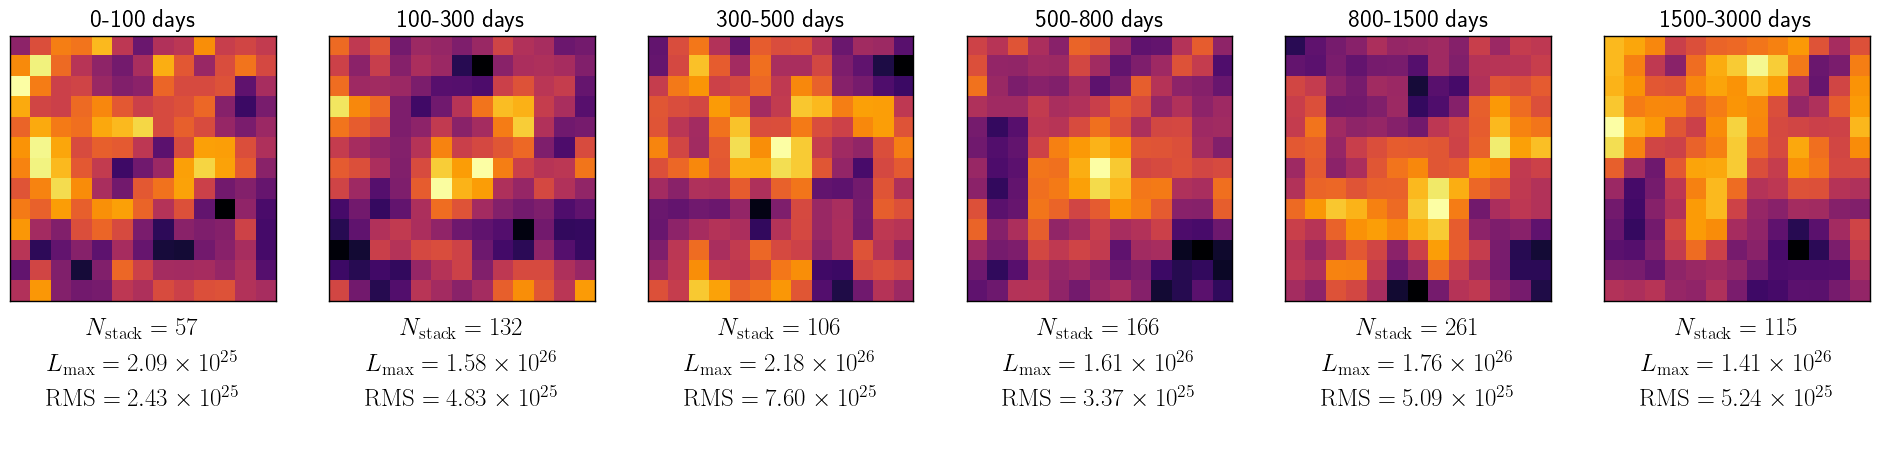

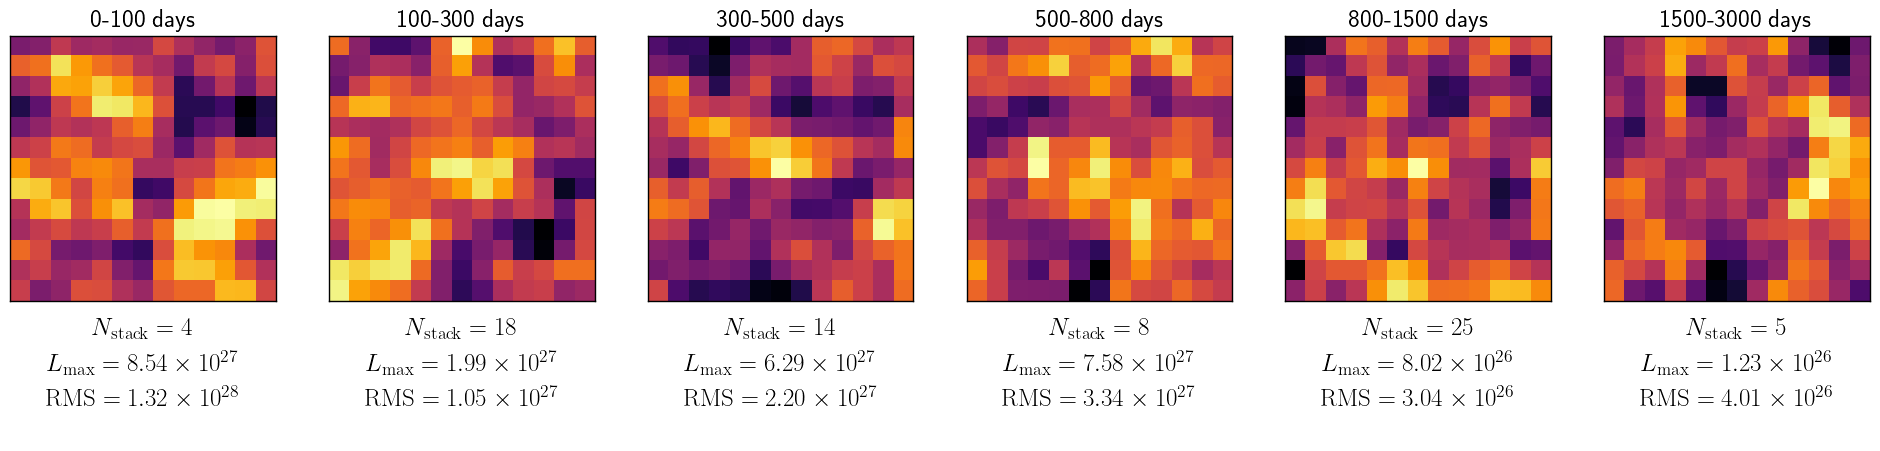

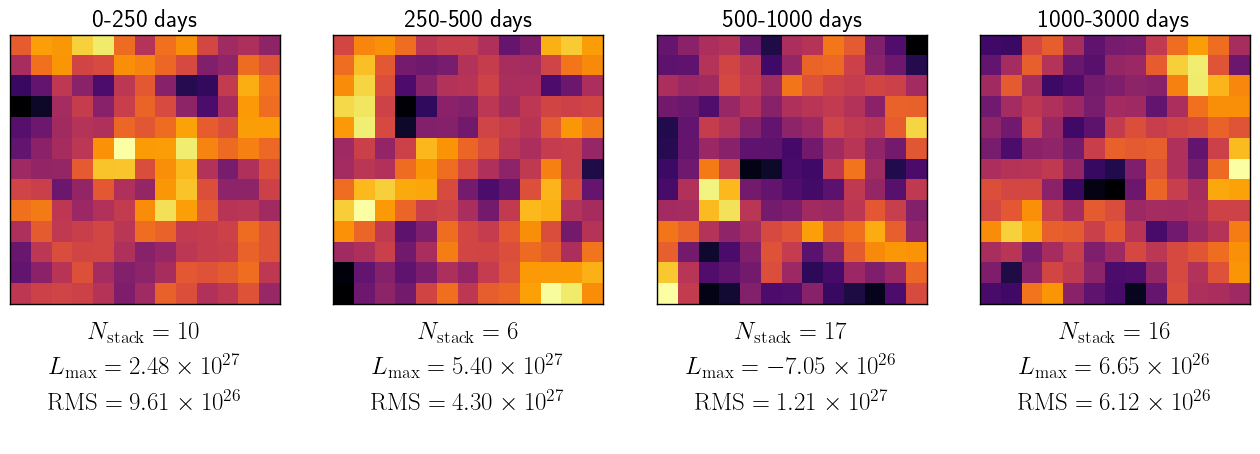

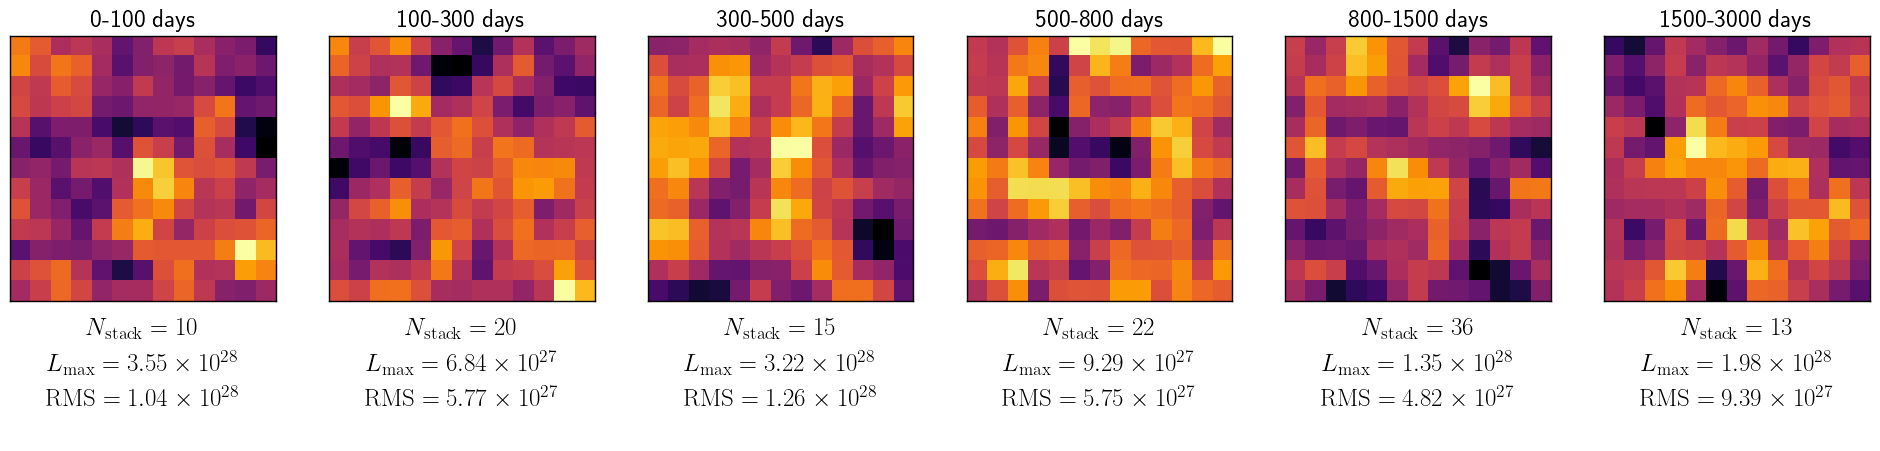

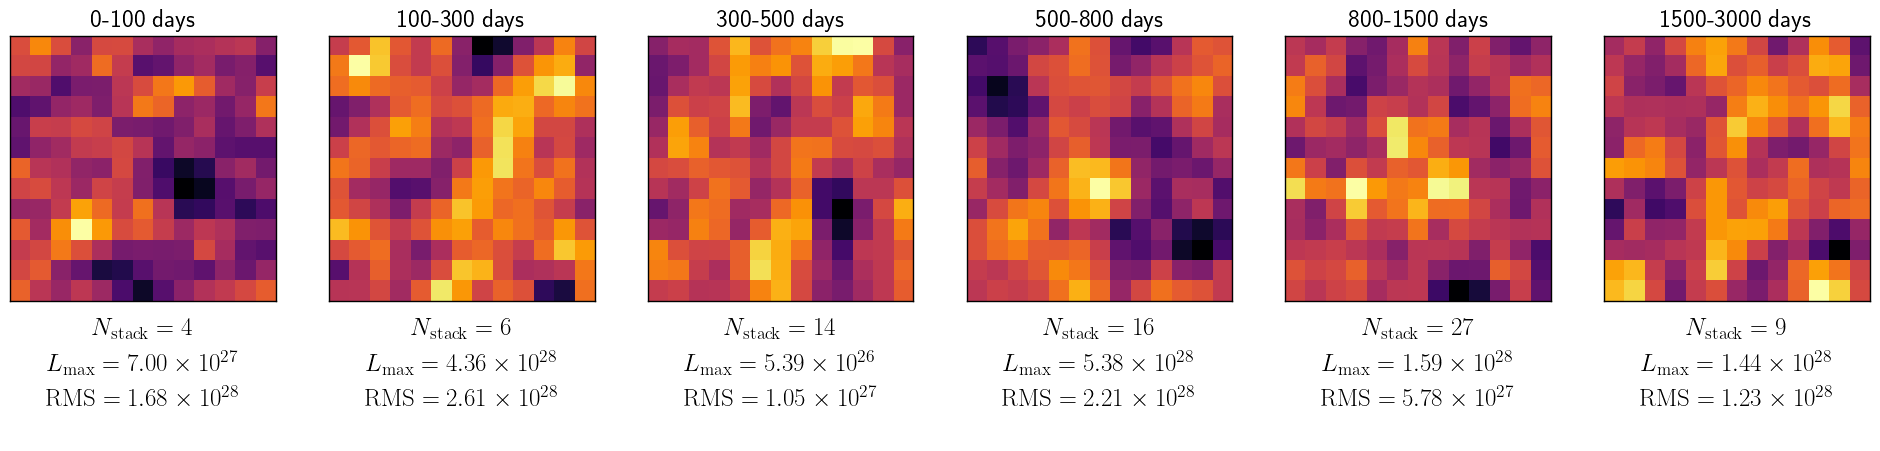

In [31]:
import os

# folder where plots will be saved
outdir = "stacked_plots"
os.makedirs(outdir, exist_ok=True)

# get all types present in the dataframe
types = filtered_stacked_df["type"].unique()

for t in types:
    safe_t = t.replace("/", "_")
    savepath = os.path.join(outdir, f"{safe_t}_stacked_plots.pdf")

    plot_stacks_for_type(
        filtered_stacked_df,
        which_type=t,
        savepath=savepath
    )

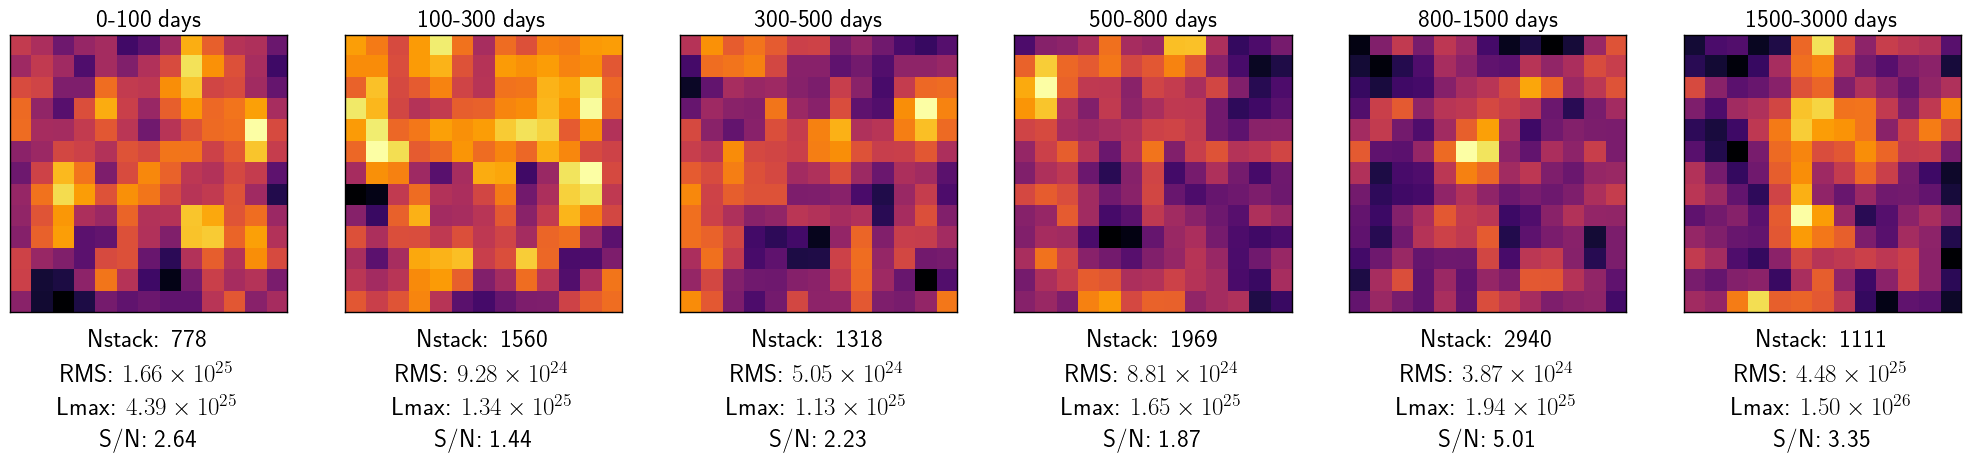

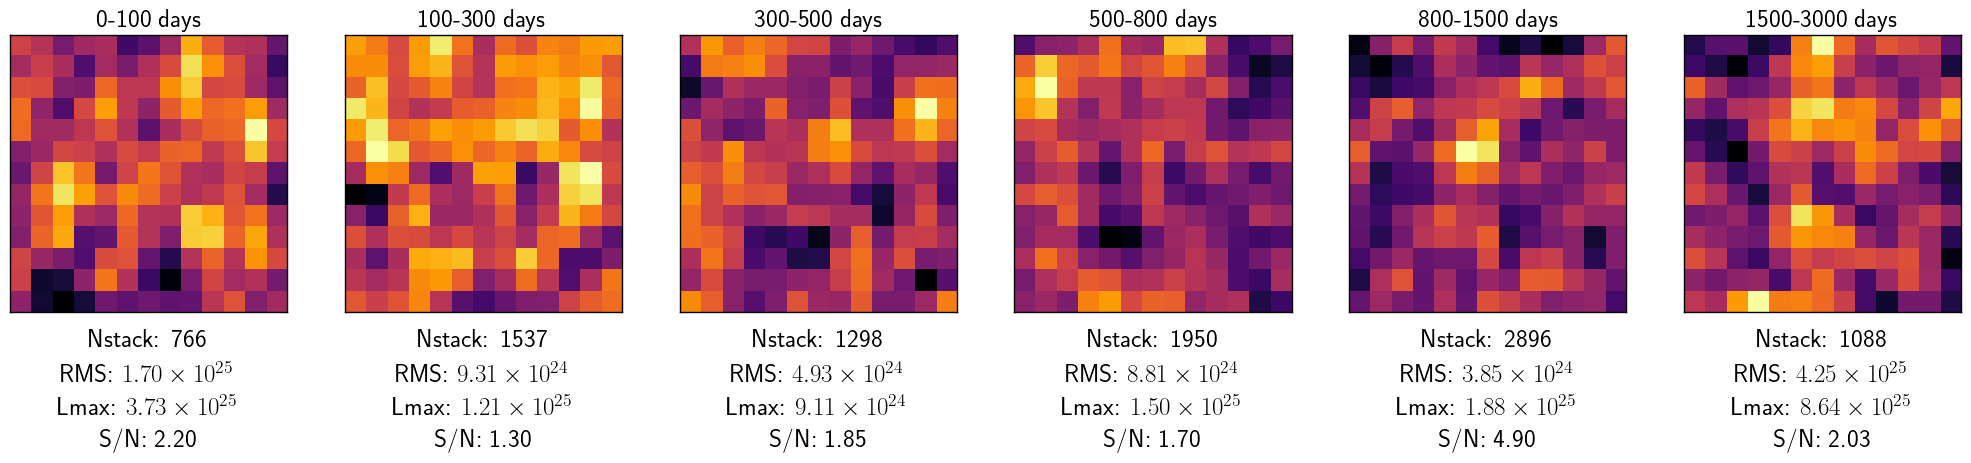

(<Figure size 2520x360 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='Nstack: 766\nRMS: $1.70 \\times 10^{25}$\nLmax: $3.73 \\times 10^{25}$\nS/N: 2.20'>,
        <Axes: title={'center': '100-300 days'}, xlabel='Nstack: 1537\nRMS: $9.31 \\times 10^{24}$\nLmax: $1.21 \\times 10^{25}$\nS/N: 1.30'>,
        <Axes: title={'center': '300-500 days'}, xlabel='Nstack: 1298\nRMS: $4.93 \\times 10^{24}$\nLmax: $9.11 \\times 10^{24}$\nS/N: 1.85'>,
        <Axes: title={'center': '500-800 days'}, xlabel='Nstack: 1950\nRMS: $8.81 \\times 10^{24}$\nLmax: $1.50 \\times 10^{25}$\nS/N: 1.70'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='Nstack: 2896\nRMS: $3.85 \\times 10^{24}$\nLmax: $1.88 \\times 10^{25}$\nS/N: 4.90'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='Nstack: 1088\nRMS: $4.25 \\times 10^{25}$\nLmax: $8.64 \\times 10^{25}$\nS/N: 2.03'>],
       dtype=object))

In [8]:
plot_stacks_for_type(unfiltered_stacked_df, which_type = "Ia",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "Ia",
                     ncols = 6)

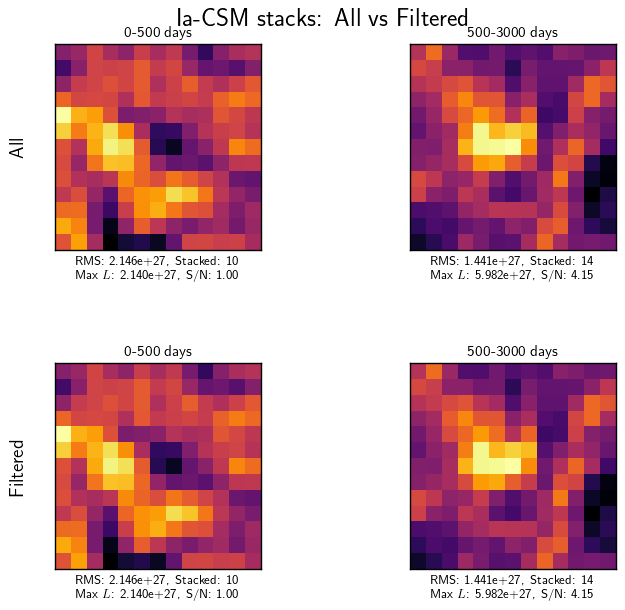

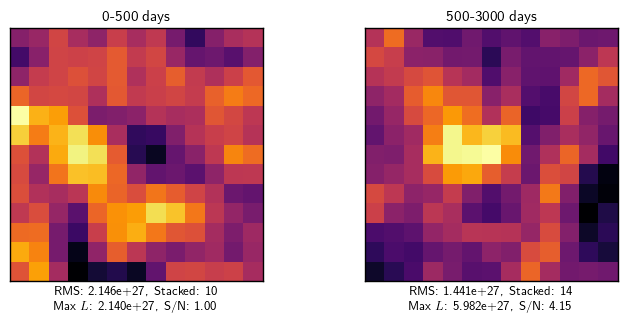

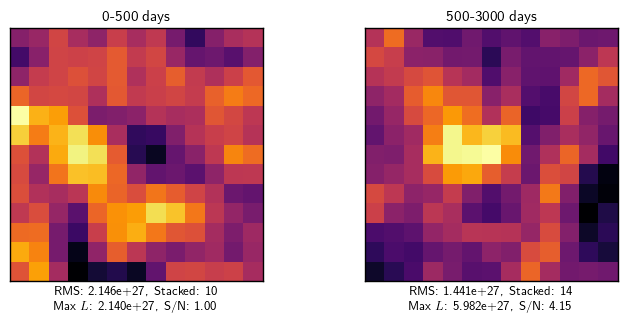

(<Figure size 840x320 with 2 Axes>,
 array([<Axes: title={'center': '0-500 days'}, xlabel='RMS: 2.146e+27, Stacked: 10\nMax $L$: 2.140e+27, S/N: 1.00'>,
        <Axes: title={'center': '500-3000 days'}, xlabel='RMS: 1.441e+27, Stacked: 14\nMax $L$: 5.982e+27, S/N: 4.15'>],
       dtype=object))

In [19]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'Ia-CSM', ncols = 2)
plot_stacks_for_type(unfiltered_stacked_df, which_type = "Ia-CSM",
                     ncols = 2)
plot_stacks_for_type(filtered_stacked_df, which_type = "Ia-CSM",
                     ncols = 2)

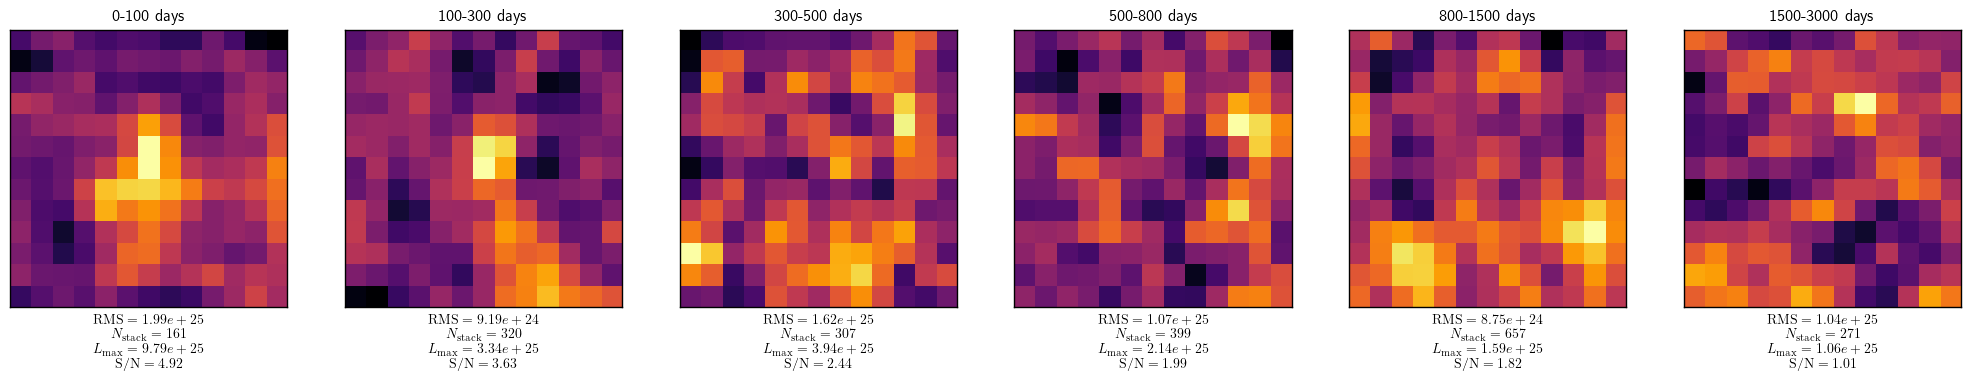

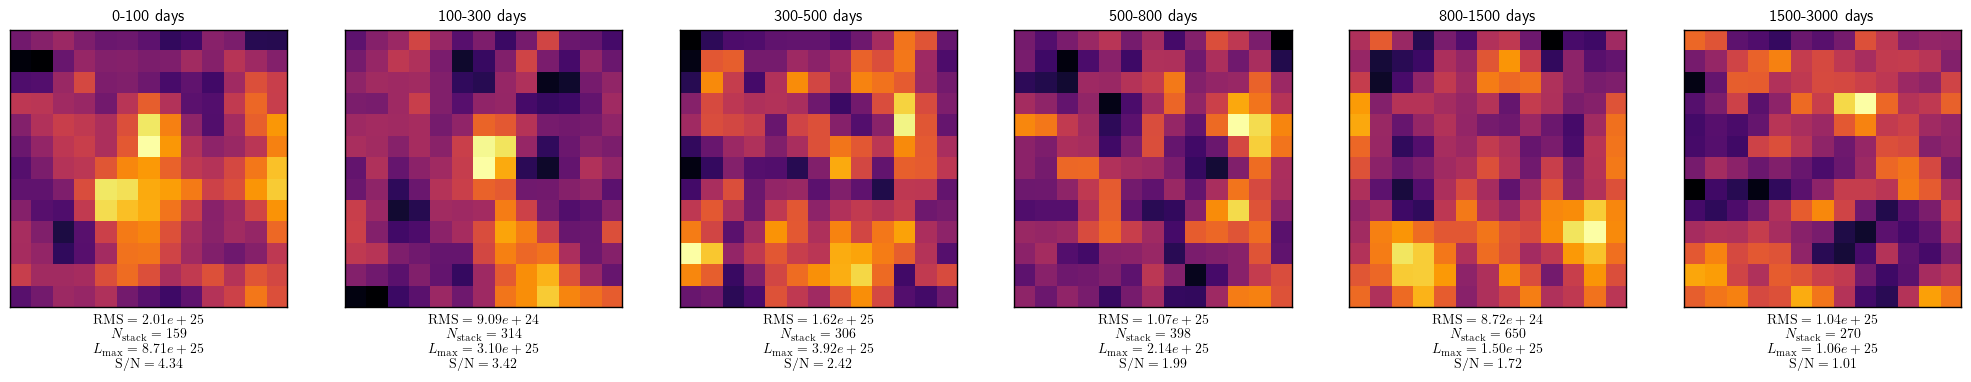

(<Figure size 2520x360 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='$\\mathrm{RMS} = 2.01e+25$\n$N_{\\mathrm{stack}} = 159$\n$L_{\\max} = 8.71e+25$\n$\\mathrm{S/N} = 4.34$'>,
        <Axes: title={'center': '100-300 days'}, xlabel='$\\mathrm{RMS} = 9.09e+24$\n$N_{\\mathrm{stack}} = 314$\n$L_{\\max} = 3.10e+25$\n$\\mathrm{S/N} = 3.42$'>,
        <Axes: title={'center': '300-500 days'}, xlabel='$\\mathrm{RMS} = 1.62e+25$\n$N_{\\mathrm{stack}} = 306$\n$L_{\\max} = 3.92e+25$\n$\\mathrm{S/N} = 2.42$'>,
        <Axes: title={'center': '500-800 days'}, xlabel='$\\mathrm{RMS} = 1.07e+25$\n$N_{\\mathrm{stack}} = 398$\n$L_{\\max} = 2.14e+25$\n$\\mathrm{S/N} = 1.99$'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='$\\mathrm{RMS} = 8.72e+24$\n$N_{\\mathrm{stack}} = 650$\n$L_{\\max} = 1.50e+25$\n$\\mathrm{S/N} = 1.72$'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='$\\mathrm{RMS} = 1.04e+25$\n$N_{\\mathrm{stack}} = 270$\n$L_{\\max} = 1.06e+25$\n$\\m

In [9]:

plot_stacks_for_type(unfiltered_stacked_df, which_type = "II",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "II",
                     ncols = 6)

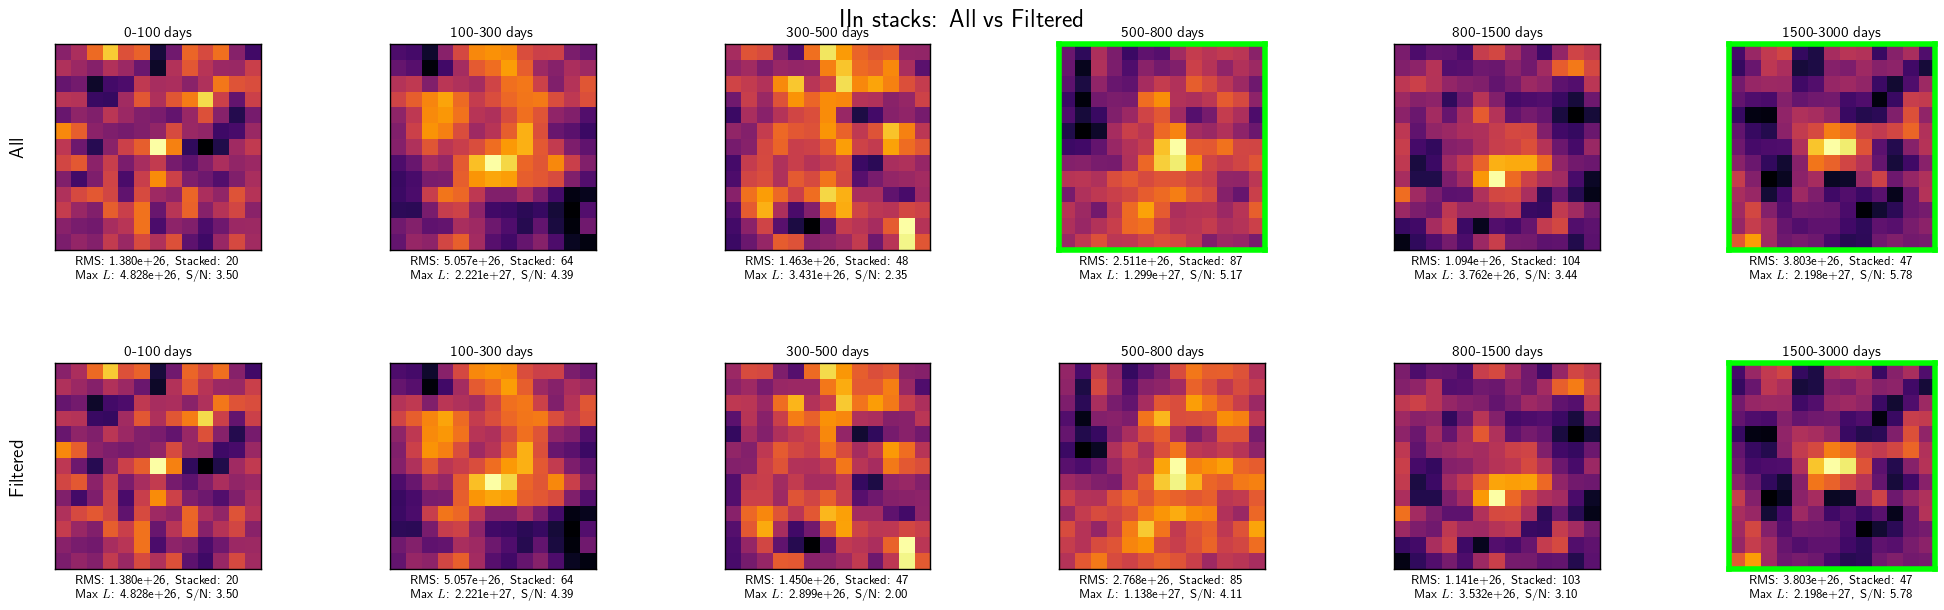

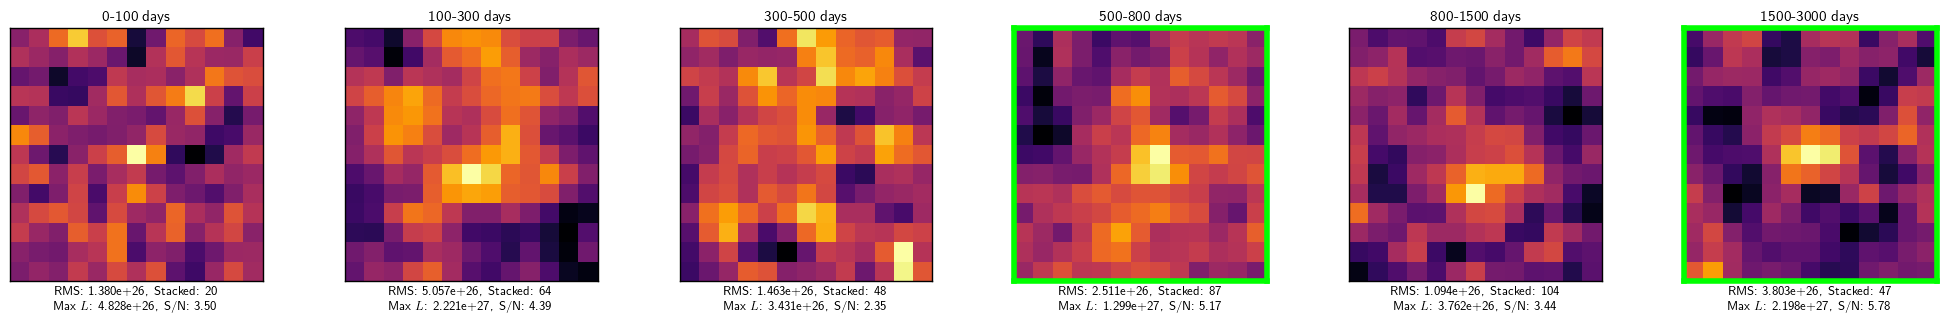

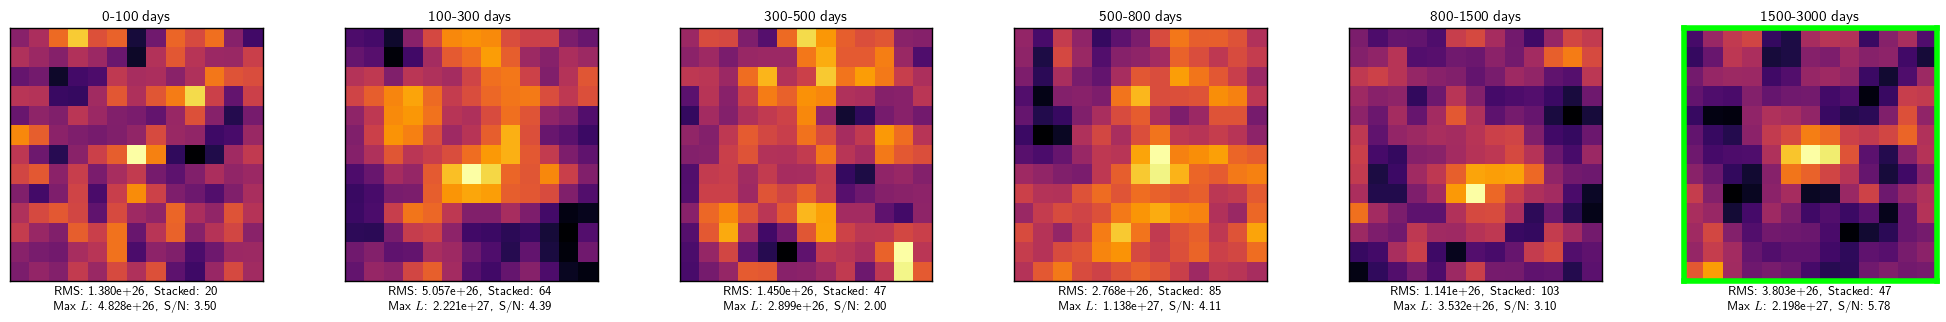

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.380e+26, Stacked: 20\nMax $L$: 4.828e+26, S/N: 3.50'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 5.057e+26, Stacked: 64\nMax $L$: 2.221e+27, S/N: 4.39'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.450e+26, Stacked: 47\nMax $L$: 2.899e+26, S/N: 2.00'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 2.768e+26, Stacked: 85\nMax $L$: 1.138e+27, S/N: 4.11'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 1.141e+26, Stacked: 103\nMax $L$: 3.532e+26, S/N: 3.10'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 3.803e+26, Stacked: 47\nMax $L$: 2.198e+27, S/N: 5.78'>],
       dtype=object))

In [20]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'IIn')

plot_stacks_for_type(unfiltered_stacked_df, which_type = "IIn",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "IIn",
                     ncols = 6)

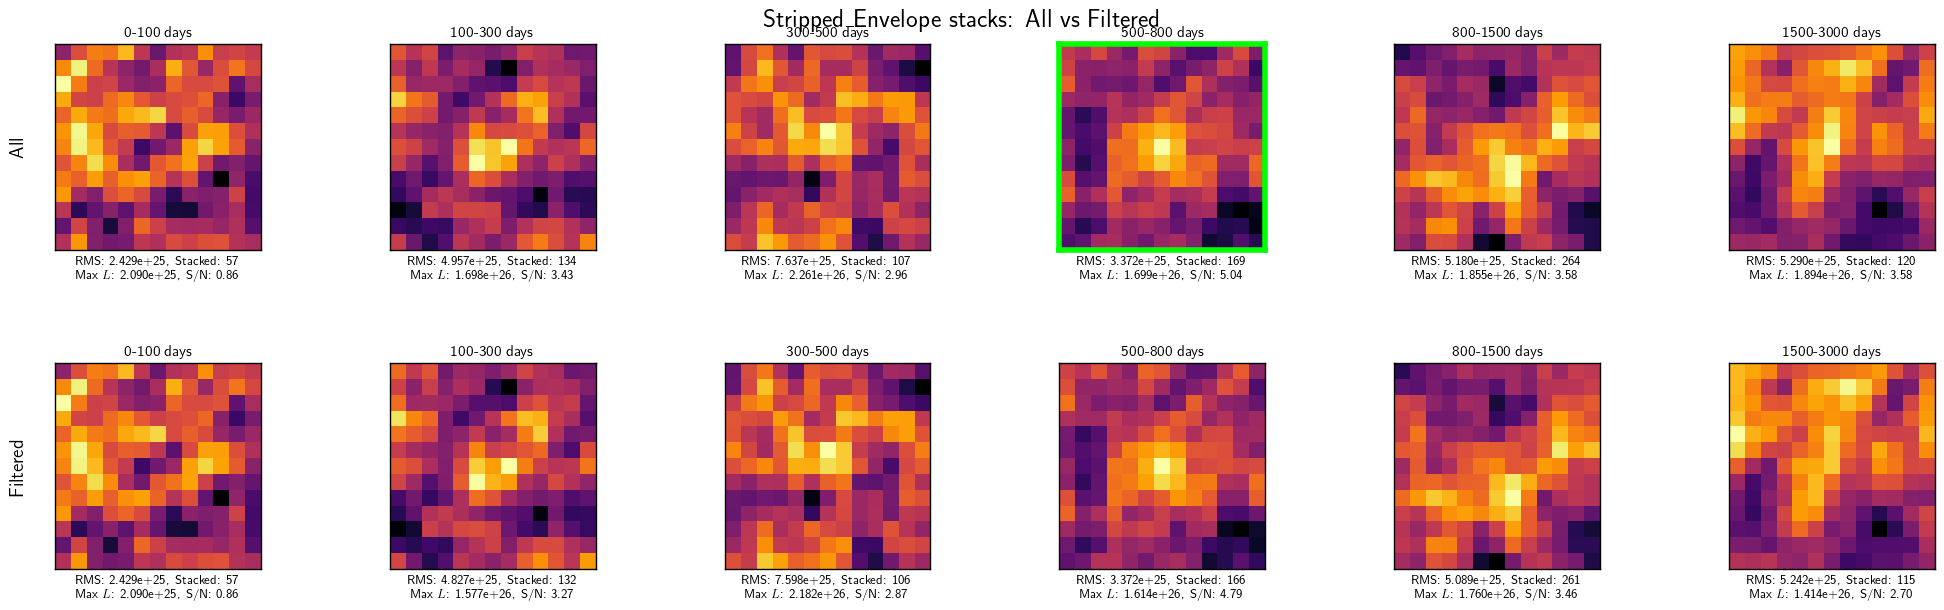

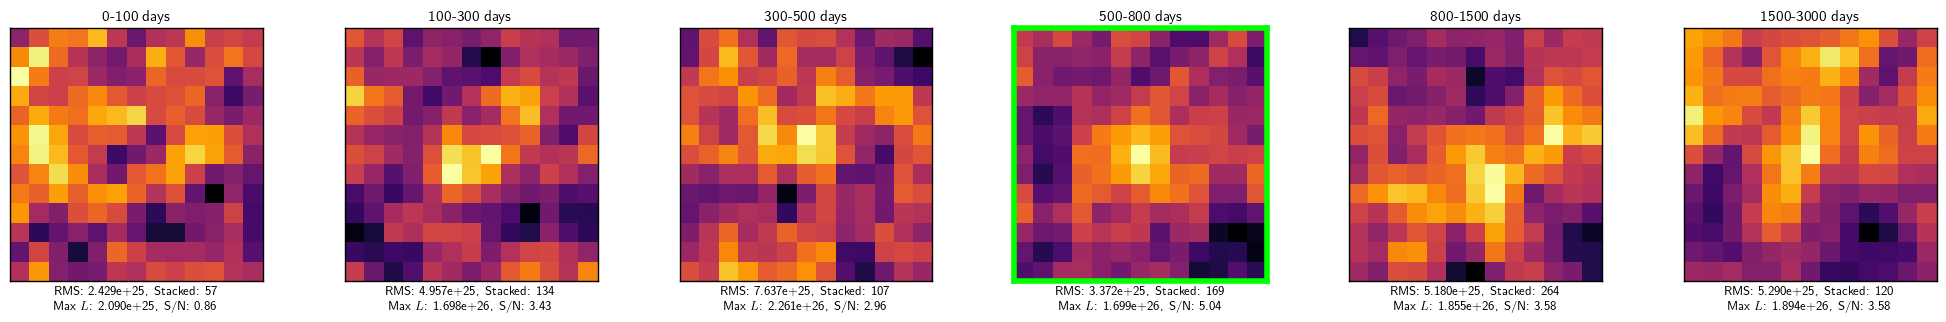

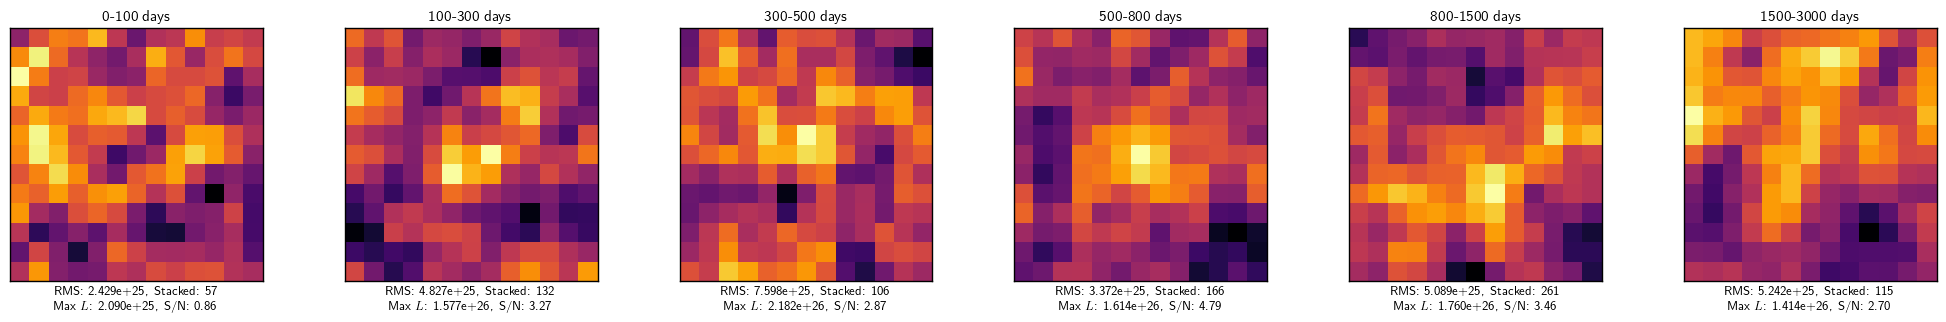

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 2.429e+25, Stacked: 57\nMax $L$: 2.090e+25, S/N: 0.86'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 4.827e+25, Stacked: 132\nMax $L$: 1.577e+26, S/N: 3.27'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 7.598e+25, Stacked: 106\nMax $L$: 2.182e+26, S/N: 2.87'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 3.372e+25, Stacked: 166\nMax $L$: 1.614e+26, S/N: 4.79'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 5.089e+25, Stacked: 261\nMax $L$: 1.760e+26, S/N: 3.46'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 5.242e+25, Stacked: 115\nMax $L$: 1.414e+26, S/N: 2.70'>],
       dtype=object))

In [21]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'Stripped_Envelope')

plot_stacks_for_type(unfiltered_stacked_df, which_type = "Stripped_Envelope",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "Stripped_Envelope",
                     ncols = 6)

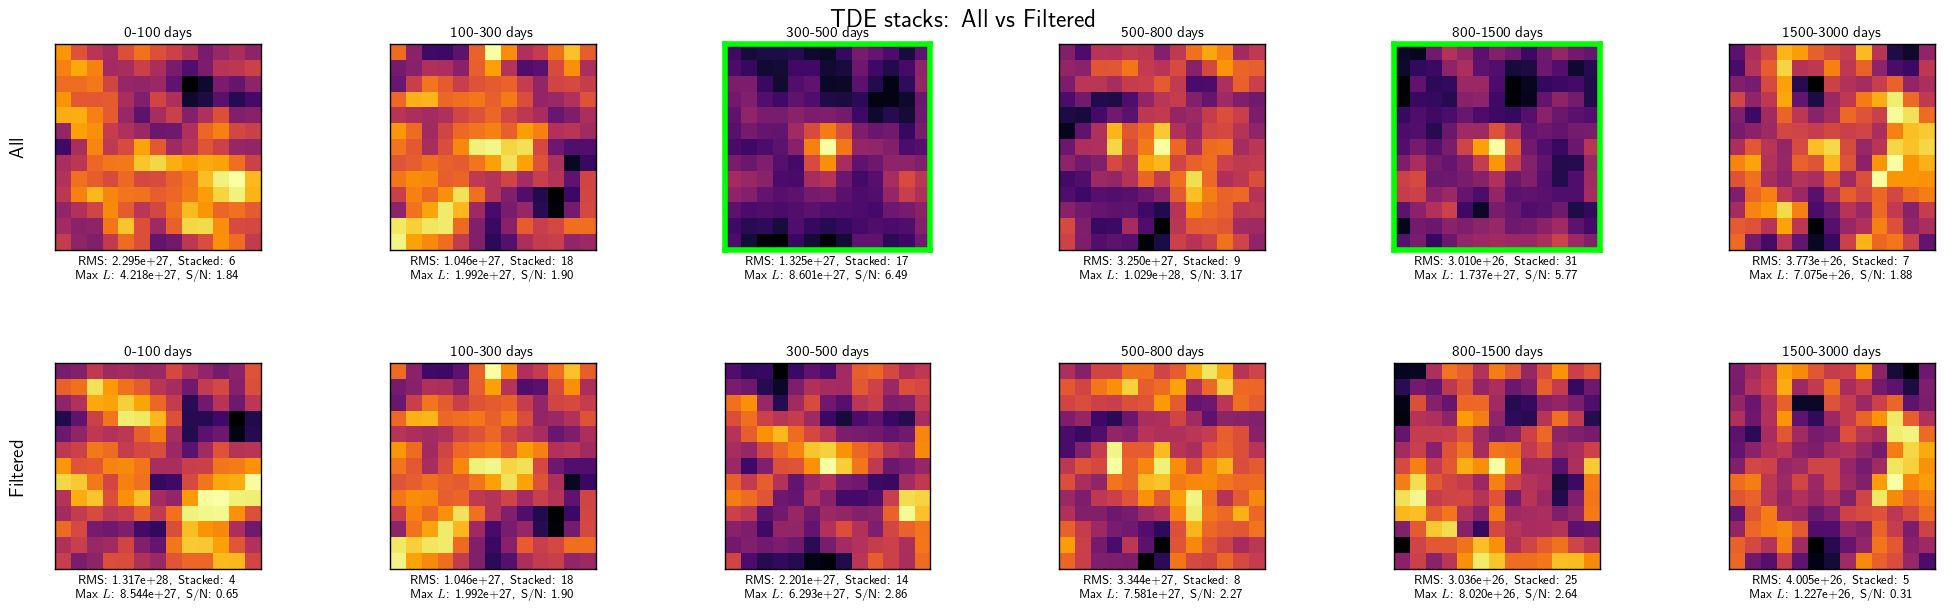

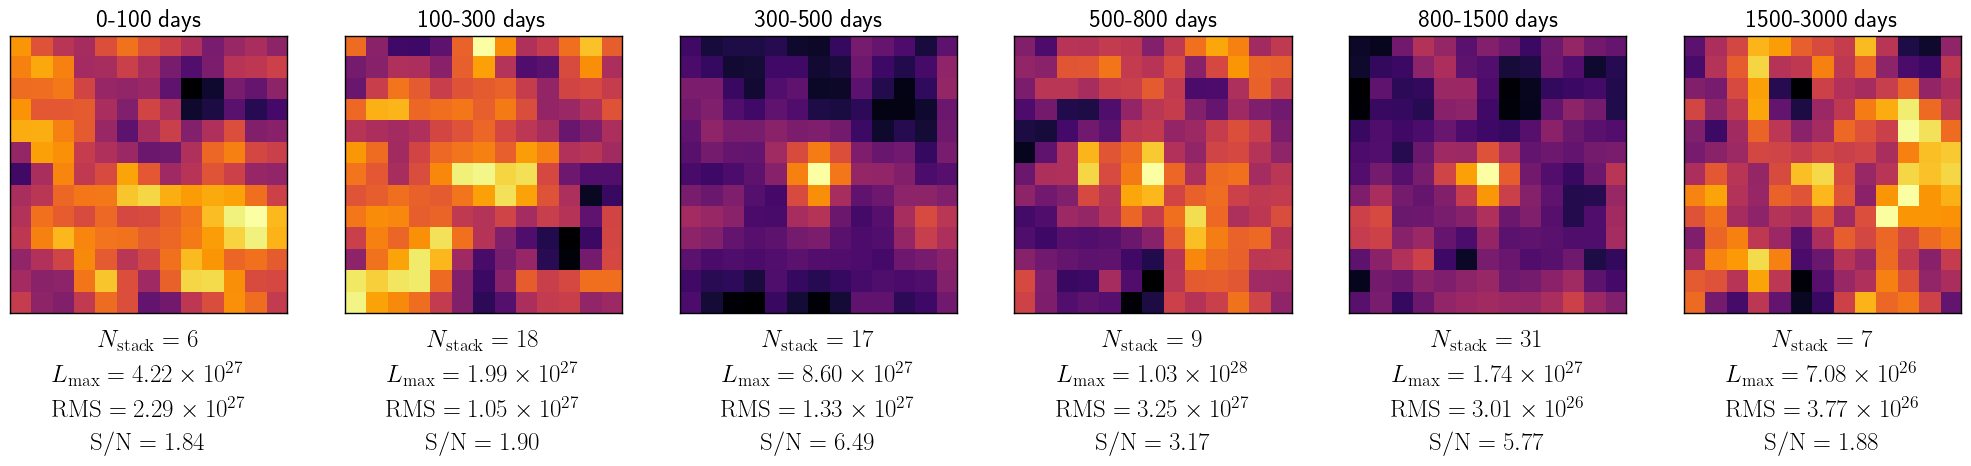

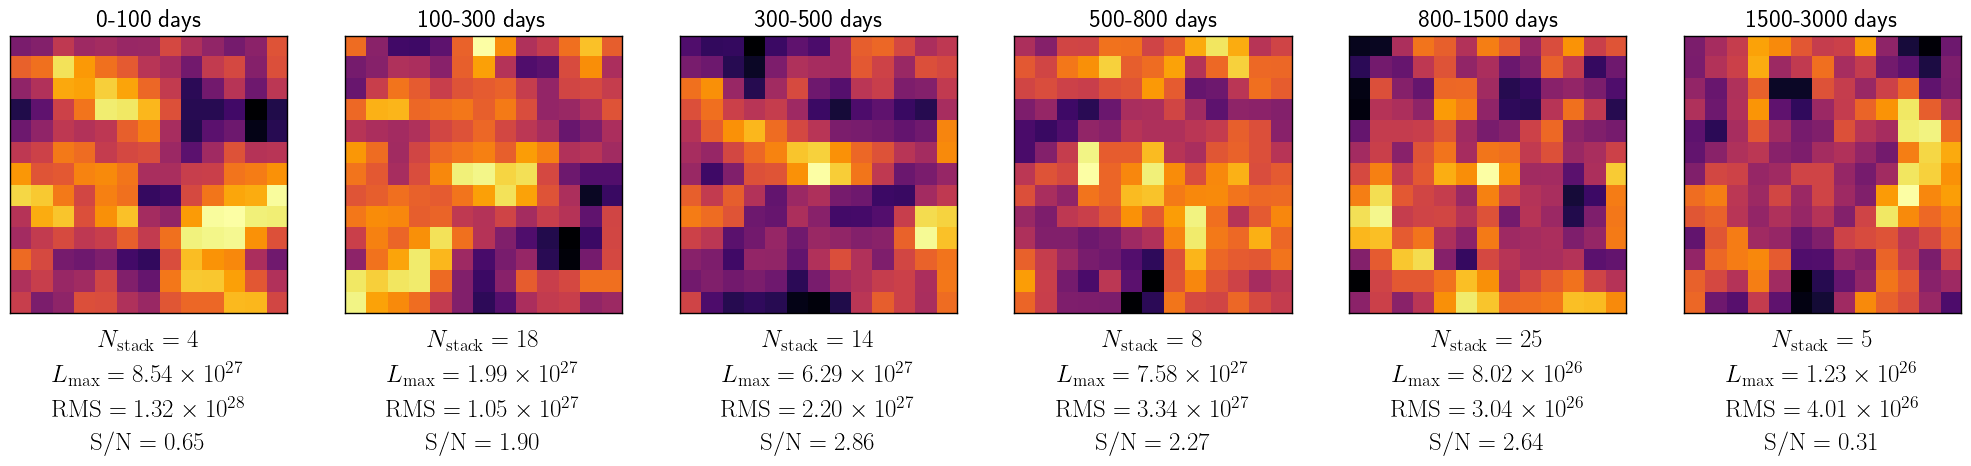

(<Figure size 2520x360 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='$N_{\\mathrm{stack}} = 4$\n$L_{\\max} = 8.54 \\times 10^{27}$\n$\\mathrm{RMS} = 1.32 \\times 10^{28}$\n$\\mathrm{S/N} = 0.65$'>,
        <Axes: title={'center': '100-300 days'}, xlabel='$N_{\\mathrm{stack}} = 18$\n$L_{\\max} = 1.99 \\times 10^{27}$\n$\\mathrm{RMS} = 1.05 \\times 10^{27}$\n$\\mathrm{S/N} = 1.90$'>,
        <Axes: title={'center': '300-500 days'}, xlabel='$N_{\\mathrm{stack}} = 14$\n$L_{\\max} = 6.29 \\times 10^{27}$\n$\\mathrm{RMS} = 2.20 \\times 10^{27}$\n$\\mathrm{S/N} = 2.86$'>,
        <Axes: title={'center': '500-800 days'}, xlabel='$N_{\\mathrm{stack}} = 8$\n$L_{\\max} = 7.58 \\times 10^{27}$\n$\\mathrm{RMS} = 3.34 \\times 10^{27}$\n$\\mathrm{S/N} = 2.27$'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='$N_{\\mathrm{stack}} = 25$\n$L_{\\max} = 8.02 \\times 10^{26}$\n$\\mathrm{RMS} = 3.04 \\times 10^{26}$\n$\\mathrm{S/N} = 2.64$'>,
        <Axes: title={'center':

In [8]:
plot_stacks_for_type_combined(unfiltered_stacked_df, filtered_stacked_df, 'TDE')

plot_stacks_for_type(unfiltered_stacked_df, which_type = "TDE",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "TDE",
                     ncols = 6)

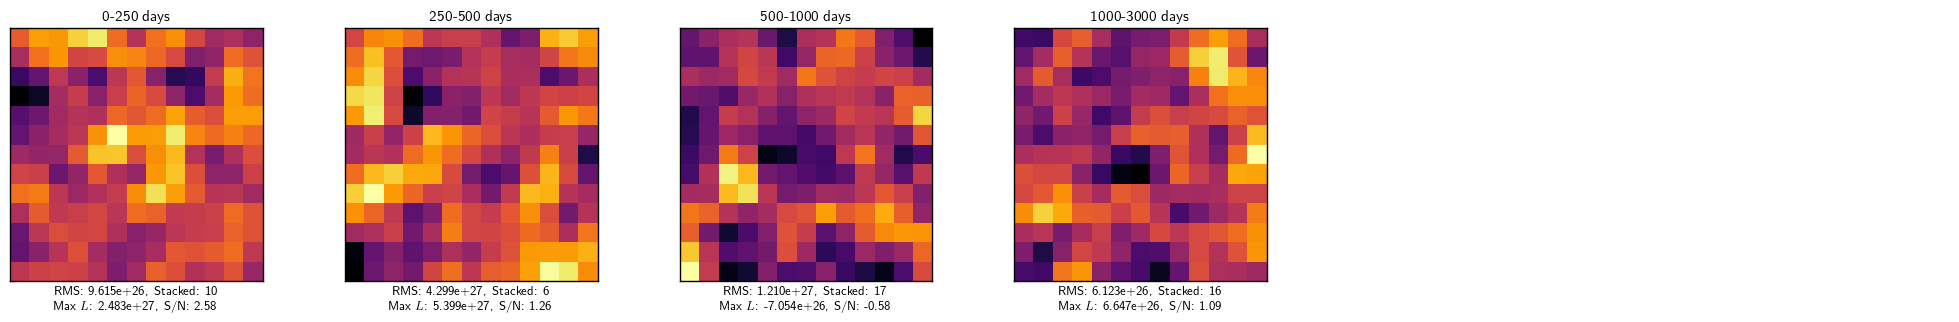

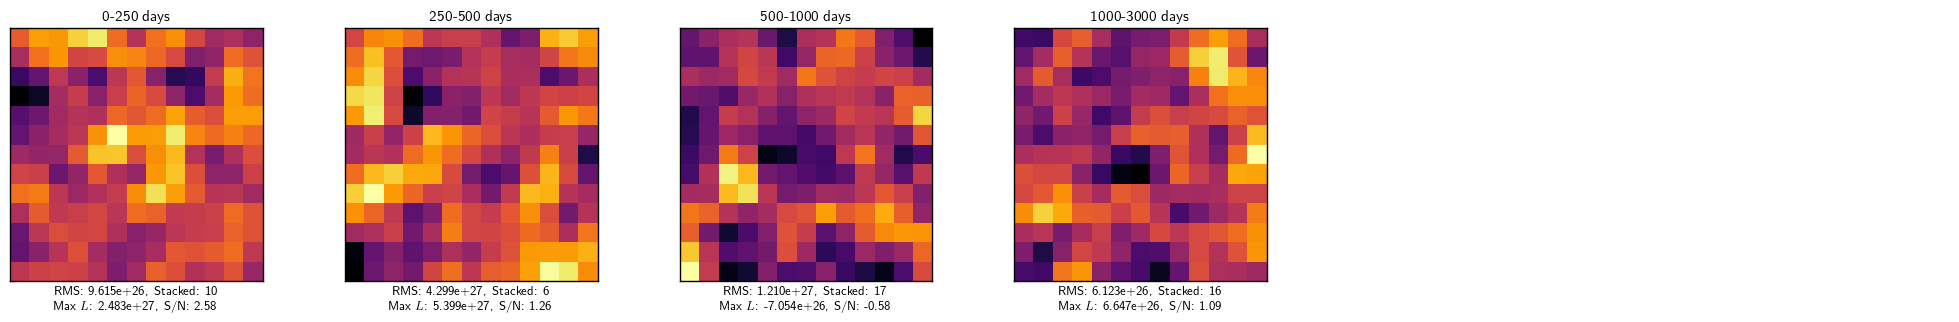

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-250 days'}, xlabel='RMS: 9.615e+26, Stacked: 10\nMax $L$: 2.483e+27, S/N: 2.58'>,
        <Axes: title={'center': '250-500 days'}, xlabel='RMS: 4.299e+27, Stacked: 6\nMax $L$: 5.399e+27, S/N: 1.26'>,
        <Axes: title={'center': '500-1000 days'}, xlabel='RMS: 1.210e+27, Stacked: 17\nMax $L$: -7.054e+26, S/N: -0.58'>,
        <Axes: title={'center': '1000-3000 days'}, xlabel='RMS: 6.123e+26, Stacked: 16\nMax $L$: 6.647e+26, S/N: 1.09'>,
        <Axes: >, <Axes: >], dtype=object))

In [23]:
plot_stacks_for_type(unfiltered_stacked_df, which_type = "Ibn/Icn",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "Ibn/Icn",
                     ncols = 6)

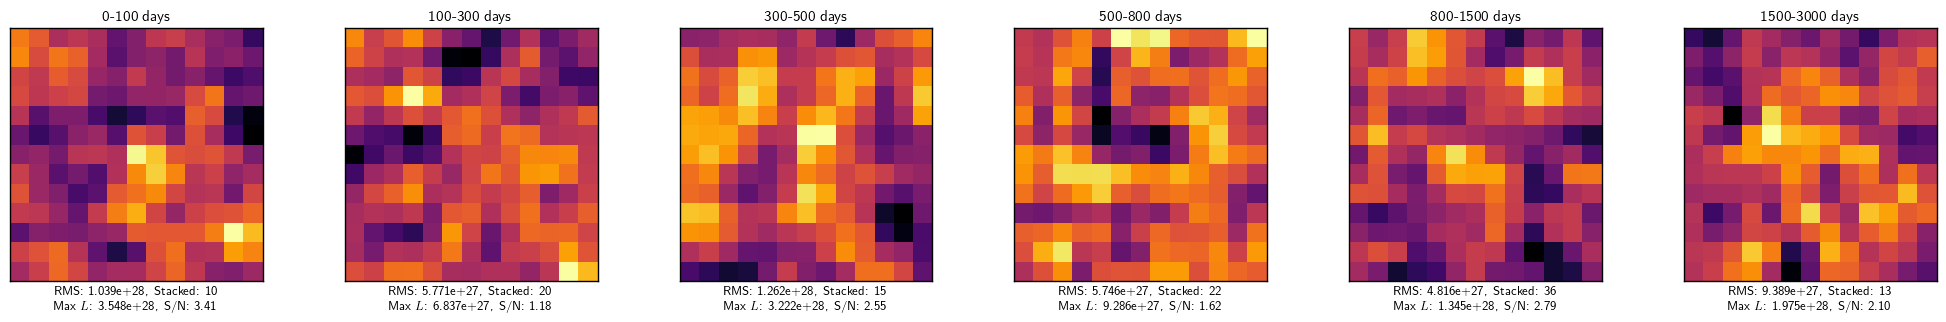

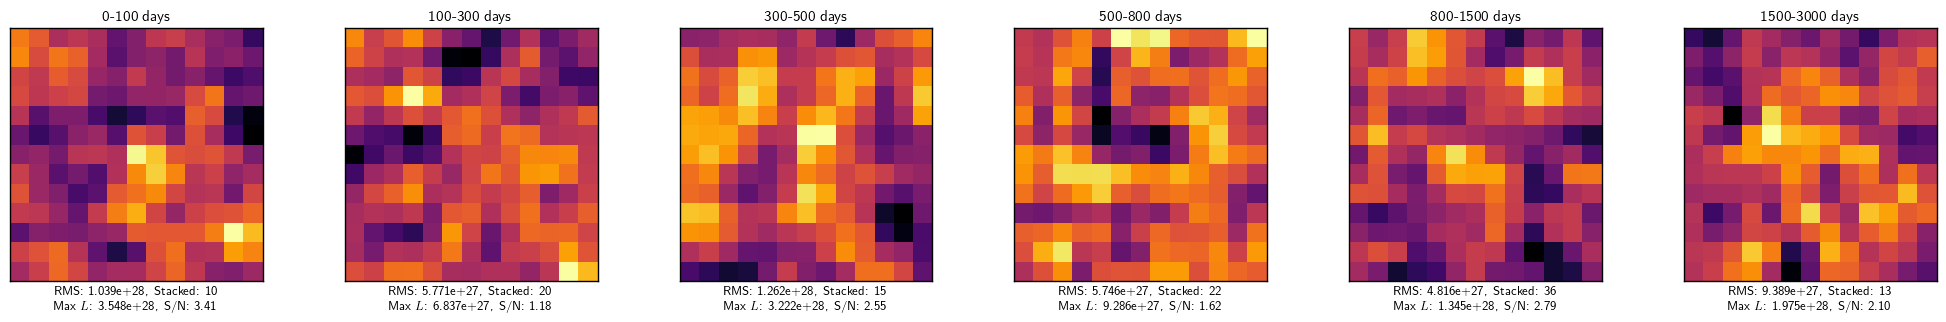

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.039e+28, Stacked: 10\nMax $L$: 3.548e+28, S/N: 3.41'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 5.771e+27, Stacked: 20\nMax $L$: 6.837e+27, S/N: 1.18'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.262e+28, Stacked: 15\nMax $L$: 3.222e+28, S/N: 2.55'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 5.746e+27, Stacked: 22\nMax $L$: 9.286e+27, S/N: 1.62'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 4.816e+27, Stacked: 36\nMax $L$: 1.345e+28, S/N: 2.79'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 9.389e+27, Stacked: 13\nMax $L$: 1.975e+28, S/N: 2.10'>],
       dtype=object))

In [24]:
plot_stacks_for_type(unfiltered_stacked_df, which_type = "SLSN-I",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "SLSN-I",
                     ncols = 6)

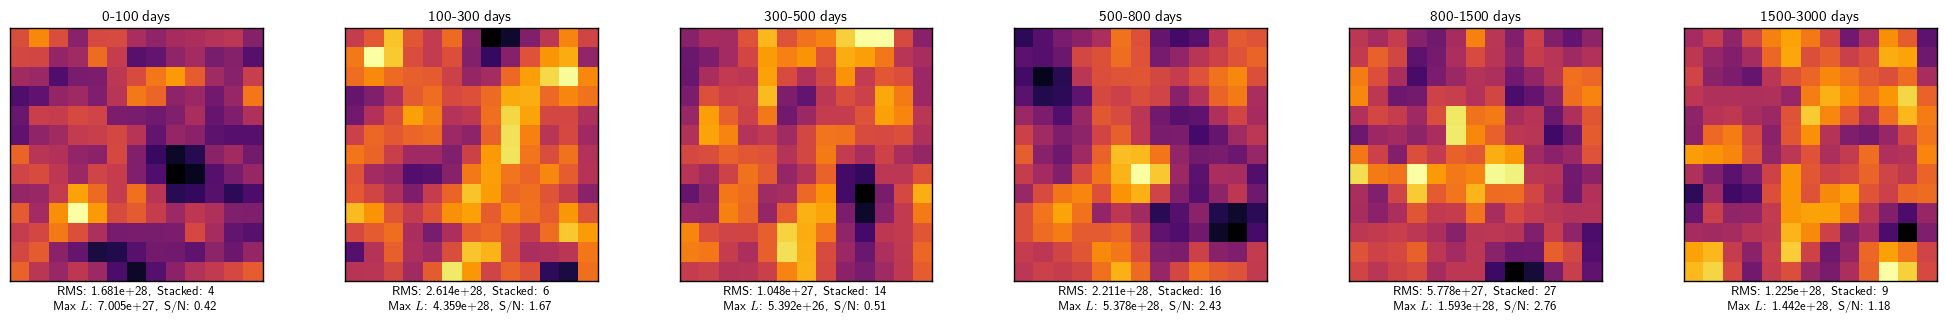

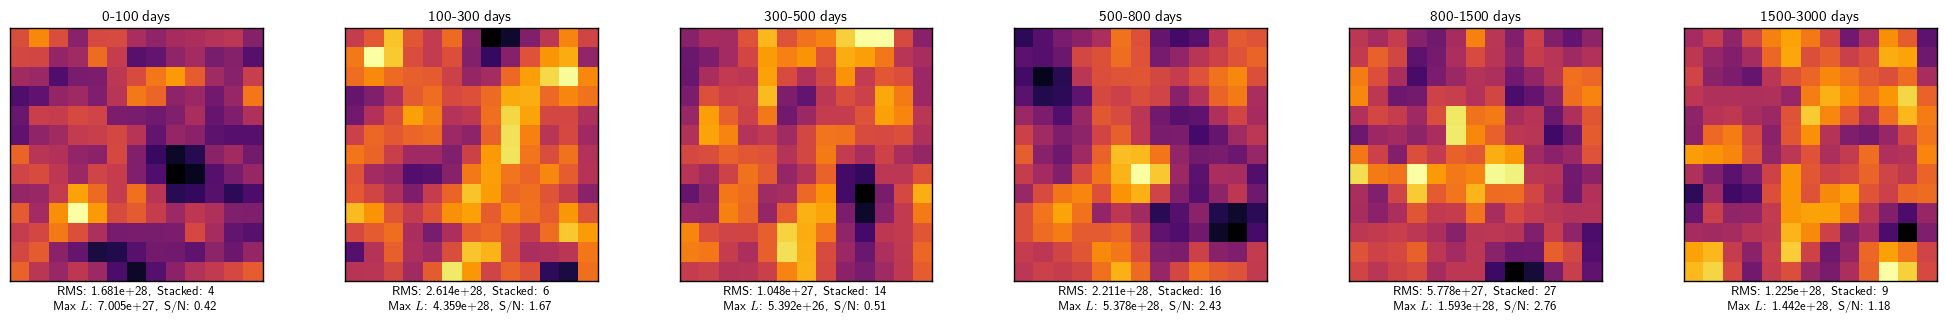

(<Figure size 2520x320 with 6 Axes>,
 array([<Axes: title={'center': '0-100 days'}, xlabel='RMS: 1.681e+28, Stacked: 4\nMax $L$: 7.005e+27, S/N: 0.42'>,
        <Axes: title={'center': '100-300 days'}, xlabel='RMS: 2.614e+28, Stacked: 6\nMax $L$: 4.359e+28, S/N: 1.67'>,
        <Axes: title={'center': '300-500 days'}, xlabel='RMS: 1.048e+27, Stacked: 14\nMax $L$: 5.392e+26, S/N: 0.51'>,
        <Axes: title={'center': '500-800 days'}, xlabel='RMS: 2.211e+28, Stacked: 16\nMax $L$: 5.378e+28, S/N: 2.43'>,
        <Axes: title={'center': '800-1500 days'}, xlabel='RMS: 5.778e+27, Stacked: 27\nMax $L$: 1.593e+28, S/N: 2.76'>,
        <Axes: title={'center': '1500-3000 days'}, xlabel='RMS: 1.225e+28, Stacked: 9\nMax $L$: 1.442e+28, S/N: 1.18'>],
       dtype=object))

In [25]:
plot_stacks_for_type(unfiltered_stacked_df, which_type = "SLSN-II",
                     ncols = 6)
plot_stacks_for_type(filtered_stacked_df, which_type = "SLSN-II",
                     ncols = 6)